In [1]:
n = 669
number_of_topics = 22
n_clusters = 15
clustering_method = "minibatch"
trained_topic_model_folder = "Subphenotyping-for-PASC_test/trained_topic_model"
print(f'results_ucsf_n{n}_{number_of_topics}topics_{n_clusters}clusters_{trained_topic_model_folder.split("_")[-1]}')

results_ucsf_n669_22topics_15clusters_model


In [2]:
import numpy as np
import pandas as pd
import re
import os
import scipy.io as sio
import openpyxl
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

import sklearn.cluster
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import umap

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import plotly.express as px
import plotly.graph_objects as go

# Loading files required to run this script

In [3]:
# Data dictionary mapping all hospitals' symptoms
data_dict = pd.read_csv("data_dictionary - Sheet1.csv").astype(str)
data_dict["Organ System"] = [str(val).lower() for val in data_dict["Organ System"]]
data_dict["Sinai Description"] = [str(val).lower() for val in data_dict["Sinai Description"]]
data_dict["UCSF Name"] = [str(val).lower() for val in data_dict["UCSF Name"]]
data_dict = data_dict.sort_values(["Organ System", "UCSF Name"]).reset_index(drop = True)
data_dict

,Organ System,Sinai Name,Sinai Description,Cardiff Name,Emory Name,UCSF Name,UCSF Description
0,cardiovascular,currentsymptoms_16,chest pain or discomfort,Chest.pain,Chest Pain (2),chest,chest pain
1,cardiovascular,currentsymptoms_17,"heart palpitations, pulse skips, heart block",Palpitations.heart.racing,Paliptations (2),heartrace,Feeling your heart pound or race
2,cognitive/psych,currentsymptoms_27,"difficulty with concentration or reading or ""b...",Poor.concentration,Brain Fog (3),concen,"trouble concentrating, trouble with your think..."
3,cognitive/psych,currentsymptoms_28,"confusion, difficulty thinking",nan,"Confusion, difficulty thinking",concen,"trouble concentrating, trouble with your think..."
4,cognitive/psych,currentsymptoms_30,memory problems or forgetfulness,nan,"Forgetful, memory problem",concen,"trouble concentrating, trouble with your think..."
...,...,...,...,...,...,...,...
56,temperature regulation,currentsymptoms_1,fever or chills,Chills..do.you.feel.unusually.cold,Fever/Chills,chills,"chills, feeling unusually cold"
57,temperature regulation,currentsymptoms_1,fever or chills,Fevers..did.you.feel.hot.,Fever/Chills,fever,are you feeling feverish
58,temperature regulation,currentsymptoms_4,unexplained sweats or flushing,Increased.body.odour.sweating,Unexplained sweat/flushing,nan,nan
59,temperature regulation,nan,nan,Runny.or.congested.nose,nan,runny,runny nose or congestion


In [4]:
# Getting trained topic model (topic_matrix, topic_proprtions)
file = f'{trained_topic_model_folder}/PFA_trained_model_n{n}_k{number_of_topics}.mat'
data = sio.loadmat(file)
print(file)

# Getting sex, comorb, symptoms as `surveys`
surveys = pd.read_csv("data_cleaned/preprocessed_n669_to1.csv")
surveys = surveys.rename(columns = {"head": 'head                                                                                  .'})

# Getting color palette for umaps
colors = list(sns.color_palette("tab20"))
colors.extend(["purple", "black", "yellow", "green", "blue", "pink"])

# Defining comorb, symptoms
comorb_list = ['auto', 'cancer', 'diab', 'heart', 'hiv', 'hosp', 'hyper', 'icu', 
               'kidney', 'lung', 'oxy', 'smk', 'student', 'venti']
symptoms = ['abdom', 'back', 'balan', 'chest', 'chills', 'concen', 'const', 'cough', 'cramps', 'diarr', 'dizz', 
            'faint', 'fatig', 'fever', #'head', 
            'head                                                                                  .', 
            'heartrace', 'loss', 'muscle', 'nausea', 'numb', 'odor', 'pain', 
            'painsex', 'rash', 'runny', 'short', 'sleep', 'smell', 'sore', 'temp', 'vision', 'vomit']

Subphenotyping-for-PASC_test/trained_topic_model/PFA_trained_model_n669_k22.mat


In [5]:
print("Organ System Mapping")
system_symptom_mapping = {}
for system in ["Neurological", "Cognitive/Psych", "Musculo-Skeletal", "G.I", "Sexual/Hormonal Function", "sensory changes", 
            "temperature regulation", "pulmonary", "cardiovascular", "other"]: 
    system_symptom_mapping[system.lower()] = []
for index, row in data_dict.iterrows(): 
    system = row["Organ System"].lower()
    symptom = row["UCSF Name"]
    if symptom == "nan": 
        continue
    symptom = symptom.lower().replace(" ", "_")
    if symptom not in system_symptom_mapping[system]: 
        system_symptom_mapping[system].append(symptom)
color_mapping, symptoms_ordered, symptoms_ordered_colors = {}, [], []
ct = 0
for system in system_symptom_mapping.keys(): 
    print("\t", system, system_symptom_mapping[system])
    for symptom in system_symptom_mapping[system]: 
        symptoms_ordered.append(symptom)
        symptoms_ordered_colors.append(colors[ct])
        color_mapping[system] = colors[ct]
    ct += 1
symptoms_ordered[symptoms_ordered.index("head")] = symptoms_ordered[symptoms_ordered.index("head")].replace('head', 'head                                                                                  .')
# Filling in missing symptoms as other (black)
# color_other = (0.75, 0.75, 0.75) # grey 
color_other = (0, 0, 0) # black
for symptom in symptoms: 
    if symptom not in symptoms_ordered: 
        symptoms_ordered.append(symptom)
        symptoms_ordered_colors.append(color_other)
        color_mapping["other"] = color_other
# print(symptoms_ordered)
# print(symptoms_ordered_colors)
# print(color_mapping)

Organ System Mapping
	 neurological ['balan', 'dizz', 'faint', 'fatig', 'head', 'sleep']
	 cognitive/psych ['concen']
	 musculo-skeletal ['back', 'cramps', 'muscle', 'pain', 'rash']
	 g.i ['abdom', 'const', 'diarr', 'loss', 'nausea', 'vomit']
	 sexual/hormonal function ['painsex']
	 sensory changes ['numb', 'odor', 'smell', 'vision']
	 temperature regulation ['chills', 'fever', 'runny', 'temp']
	 pulmonary ['cough', 'short', 'sore']
	 cardiovascular ['chest', 'heartrace']
	 other []


In [6]:
# # Getting symptom to organ system mapping
# file_ = open('Neurological_Symptom_Mapping.txt','r')
# mapping = [val.lower().replace("\n", "").replace("\t", "") for val in file_.readlines()]
# file_.close()
# neurologicals = [val.lower() for val in ["Neurological", "Cognitive/Psych", "Musculo-Skeletal", "G.I", "Sexual/Hormonal Function", "sensory changes", "temperature regulation", "pulmonary", "cardiovascular"]]
# neurological_symptom_mapping, color_mapping, symptoms_ordered, symptoms_ordered_colors = {}, {}, [], []
# curr, ct = "", -1
# for val in mapping: 
#     val = val.replace("\t", "").lower()
#     if val in neurologicals: 
#         curr = val
#         ct += 1
#     else: 
#         if val not in symptoms: 
#             if val == "abnormal changes in body temp": val = "Abnormal changes in body temperature".lower()
#             elif val == "unexplained sweats or flushin": val = "Unexplained sweats or flushing".lower()
#             elif val == "head                                                                                  .": 
#                 val = "head"
#         subset = data_dict[data_dict["Sinai Description"] == val]
#         subset = subset[subset["UCSF Name"] != "nan"]
#         if subset.shape[0] == 1: 
#             val_new = list(subset["UCSF Name"])[0]
#             if len(symptoms_ordered) > 0 and val_new == symptoms_ordered[-1]: 
#                 continue
# #             print(val, "::", val_new)
#             symptoms_ordered.append(val_new)
#             symptoms_ordered_colors.append(colors[ct])
#             color_mapping[curr] = colors[ct]
# symptoms_ordered[symptoms_ordered.index("head")] = symptoms_ordered[symptoms_ordered.index("head")].replace('head', 'head                                                                                  .')
# # Filling in missing symptoms as other (black)
# color_other = (0.75, 0.75, 0.75) # grey 
# color_other = (0, 0, 0) # black
# for symptom in symptoms: 
#     if symptom not in symptoms_ordered: 
#         symptoms_ordered.append(symptom)
#         symptoms_ordered_colors.append(color_other)
#         color_mapping["other"] = color_other
# print(len(symptoms_ordered), "symptoms")
# print(len(color_mapping.keys()),  "symptom groups")

In [7]:
# Helper functions
def get_clusters(method, n_clusters): 
    method = method.lower()
    if method == "kmeans": 
        clusters = sklearn.cluster.KMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "minibatch": 
        clusters = sklearn.cluster.MiniBatchKMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "spectralclustering": 
        clusters = sklearn.cluster.SpectralClustering(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "birch": 
        clusters = sklearn.cluster.Birch(n_clusters = n_clusters).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "agglomerativeclustering": 
        clusters = sklearn.cluster.AgglomerativeClustering(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "bisectingkmeans": 
        clusters = sklearn.cluster.BisectingKMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    # Sorting by cluster sizes
    dictionary = sorted(dict(Counter(clusters)).items(), key=lambda x:x[1])
    dictionary.reverse()
    # [(1, 183), (3, 94), (5, 88), (9, 68), (2, 59), (8, 52), (7, 50), (4, 39), (6, 36)]
    mapping = dict(zip([val[0] for val in dictionary], np.unique(clusters))) # new:original
    # {1: 1, 3: 2, 5: 3, 9: 4, 2: 5, 8: 6, 7: 7, 4: 8, 6: 9}
    clusters = [mapping[val] for val in clusters]
    df = pd.DataFrame()
    df[0] = clusters
    dictionary = sorted(dict(Counter(clusters)).items(), key=lambda x:x[1])
    dictionary.reverse()
    return clusters

def plot_clusters(clusters, embedding, title, colors, topic_proportions_, highlights): 
    plt.figure()
    fig, ax = plt.subplots()
    plt.title(title)
    legend_elements = [] 
    for i in np.unique(clusters):
        a = plt.scatter(embedding[clusters==i, 0], embedding[clusters==i, 1], c = colors[i], s = 5)
        label = f"C{i}: {dict(Counter(clusters))[i]}"
        legend_elements.append(Line2D([0], [0], label = label, markerfacecolor = colors[i], markersize = 5, marker = 'o', color = 'w'))
        if highlights: 
            indeces = topic_proportions_[topic_proportions_["cluster"] == i].index
            indeces = list(set(indeces) & set(patients))
            a = plt.scatter(embedding[indeces, 0], embedding[indeces, 1], c = colors[i], s = 100, alpha = 0.5, marker = "^")
    ax.legend(handles = legend_elements, bbox_to_anchor=(1, 1))

# Topic Matrix Heatmap

32 symptoms 22 topics
T1    1.0
T2    1.0
T3    1.0
dtype: float64
balan    0.470318
dizz     0.539003
faint    0.045097
dtype: float64
trained_topic_model/PFA_trained_model_n669_k22.mat


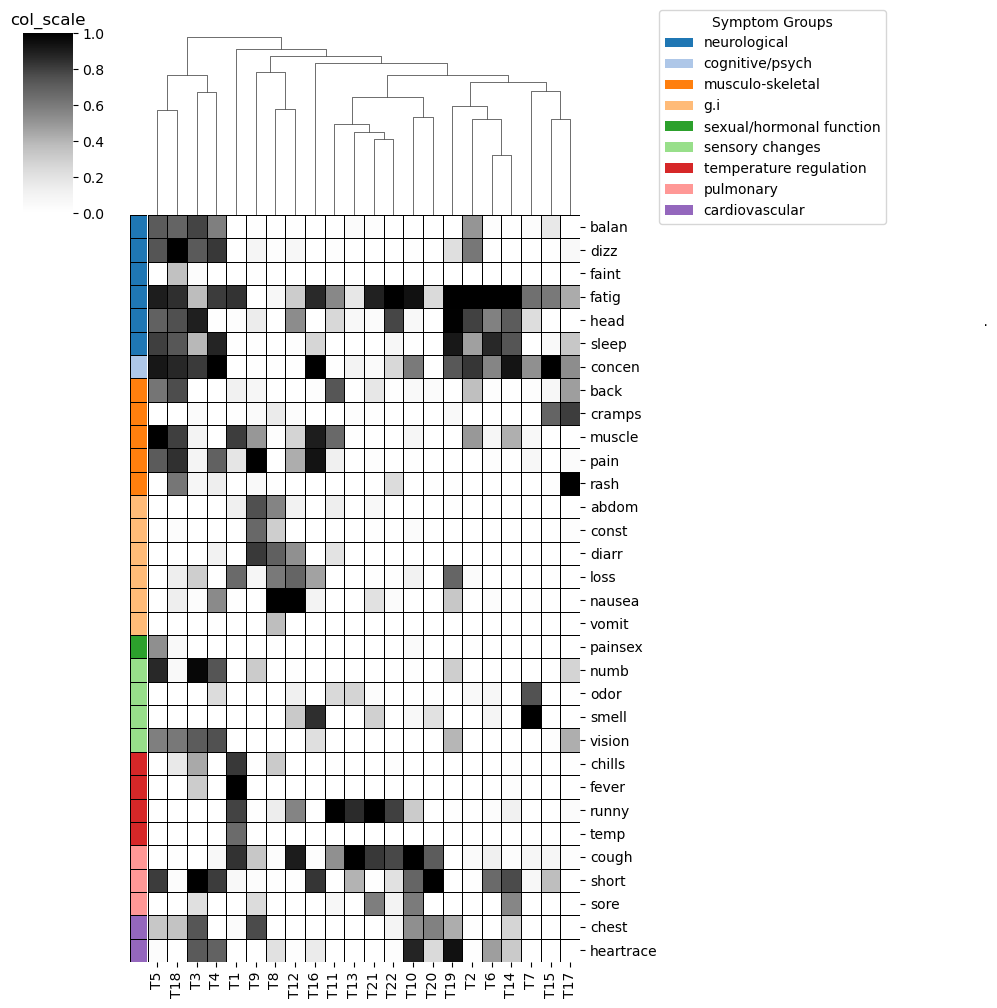

In [8]:
topic_matrix = pd.DataFrame(data['Phi_mean'])
print(topic_matrix.shape[0], "symptoms", topic_matrix.shape[1], "topics")
topic_matrix.columns = ["T" + str(val) for val in range(1, topic_matrix.shape[1] + 1)]
topic_matrix.index = pd.CategoricalIndex(symptoms, categories = symptoms_ordered)
topic_matrix = topic_matrix.sort_index()
# topic_matrix = topic_matrix.div(topic_matrix.sum(axis=1), axis=0) #### row-wise normalizing
print(topic_matrix.sum(0)[:3])
print(topic_matrix.sum(1)[:3])
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


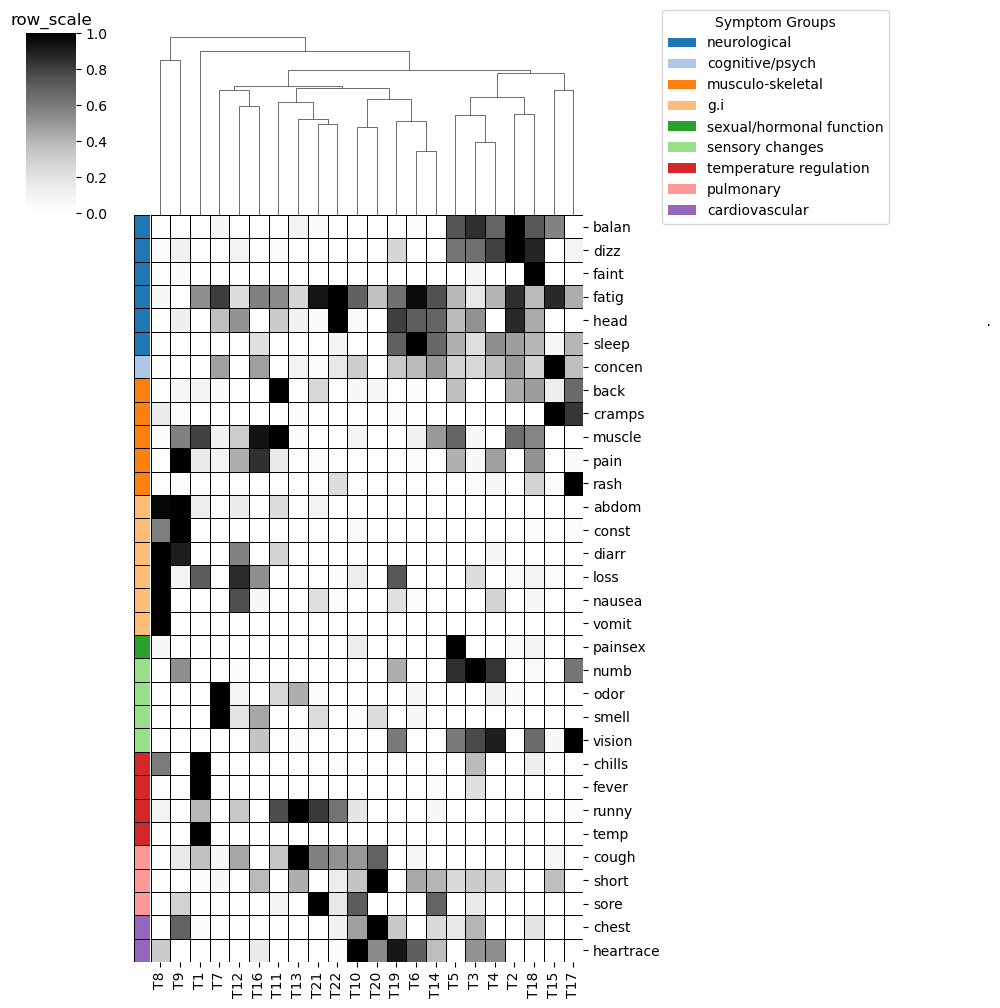

In [9]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


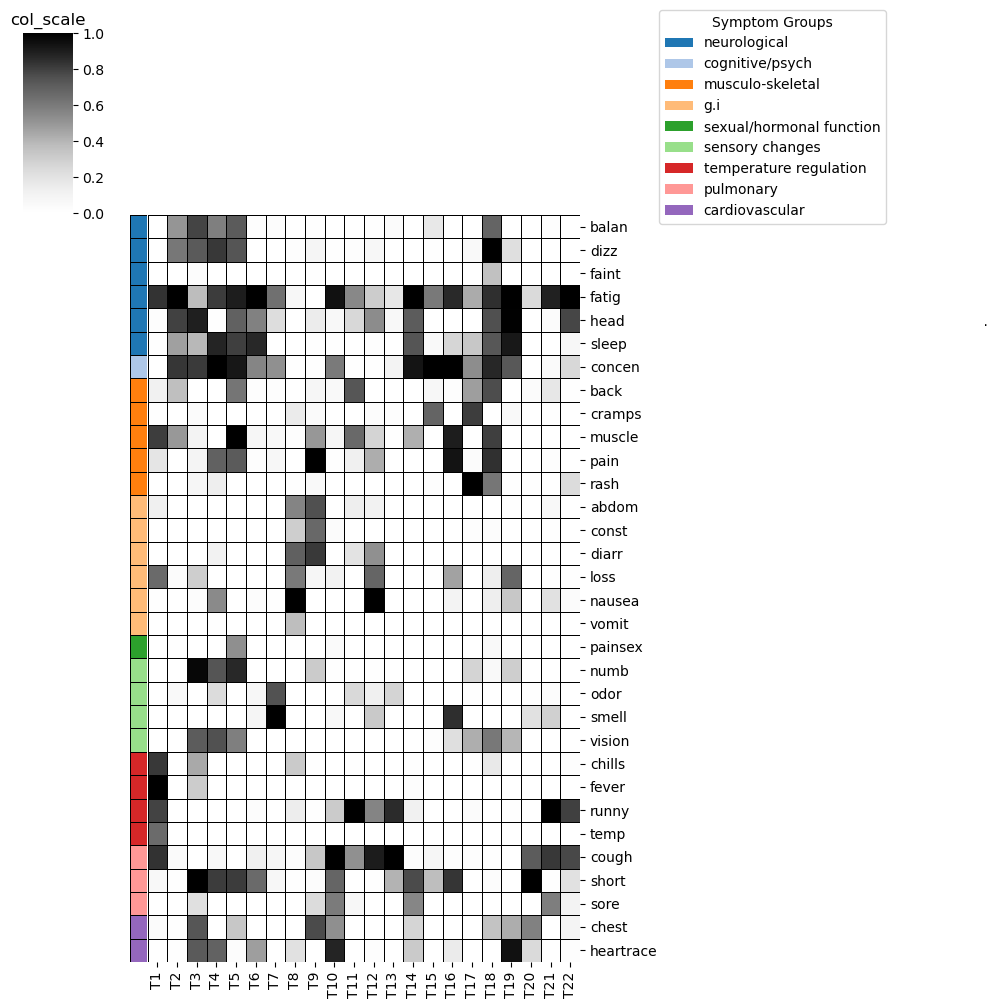

In [10]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("col_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


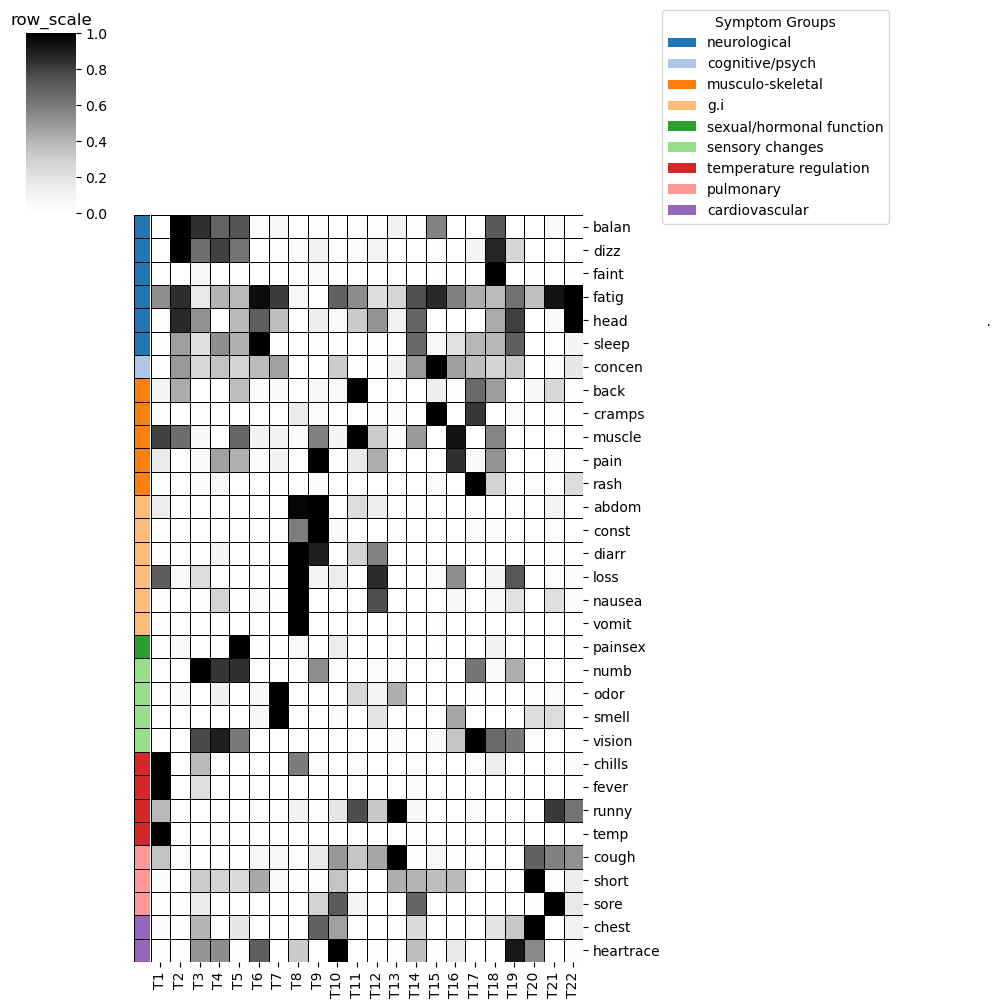

In [11]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


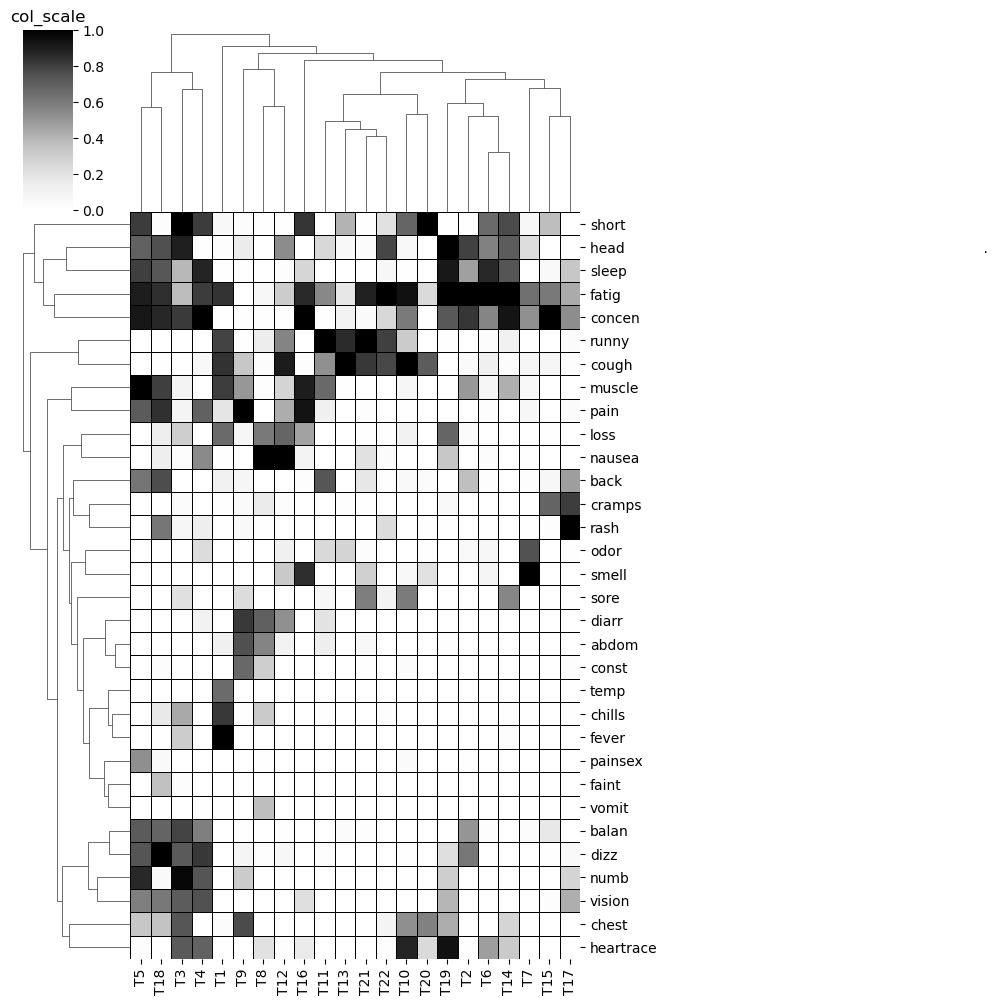

In [12]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = True, #row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


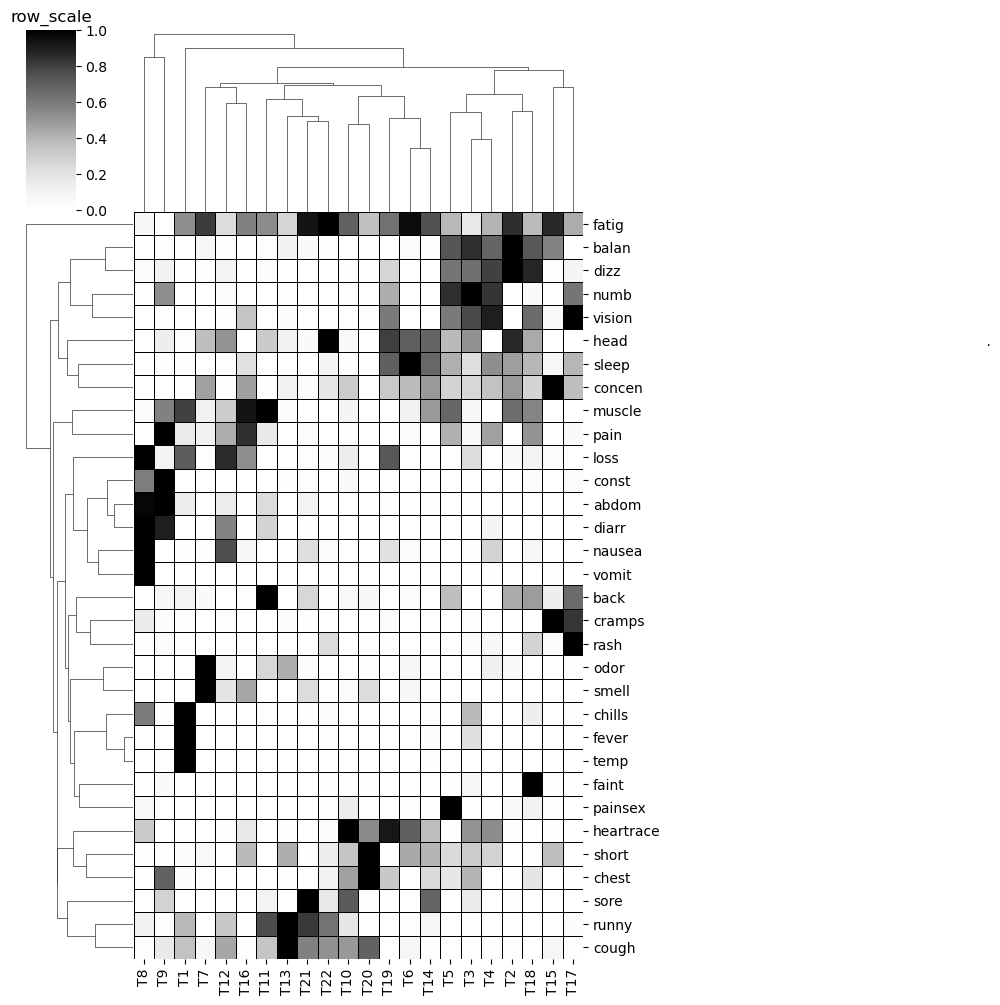

In [13]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = True, #row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

# Clustering

Counter({1: 251, 2: 63, 4: 34, 3: 34, 5: 33, 6: 32, 7: 31, 9: 29, 8: 29, 10: 26, 11: 25, 12: 23, 13: 22, 14: 21, 15: 16})
trained_topic_model/PFA_trained_model_n669_k22.mat


<Figure size 640x480 with 0 Axes>

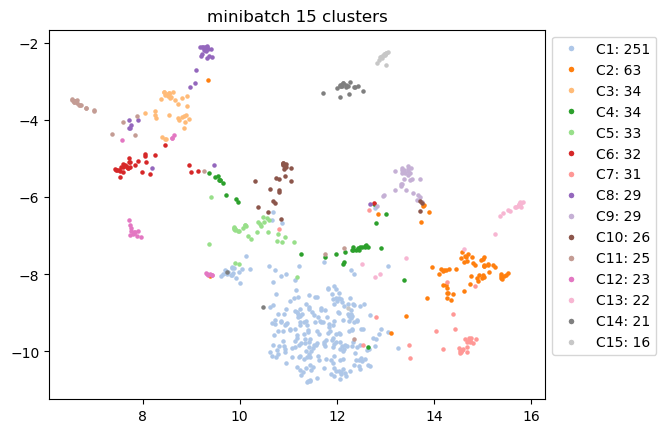

In [14]:
topic_proportions = pd.DataFrame(data['Theta_mean']).T
topic_proportions_norm = topic_proportions/topic_proportions.sum(1)[:,np.newaxis]
topic_proportions_norm = preprocessing.normalize(topic_proportions)
UMAP = umap.UMAP(metric='euclidean', n_neighbors=30, random_state=916)
embedding = UMAP.fit_transform(topic_proportions_norm)
clusters = get_clusters(clustering_method, n_clusters)

#### Manually defining the clusters ####
df = pd.read_csv("clusters_minibatch_15 - Copy.csv", header = None)
clusters = list(df[0])

topic_proportions_ = pd.DataFrame(topic_proportions).copy()
topic_proportions_["cluster"] = clusters
print(Counter(clusters))
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')
plot_clusters(clusters, embedding, f"{clustering_method} {n_clusters} clusters", colors, None, None)

<Figure size 640x480 with 0 Axes>

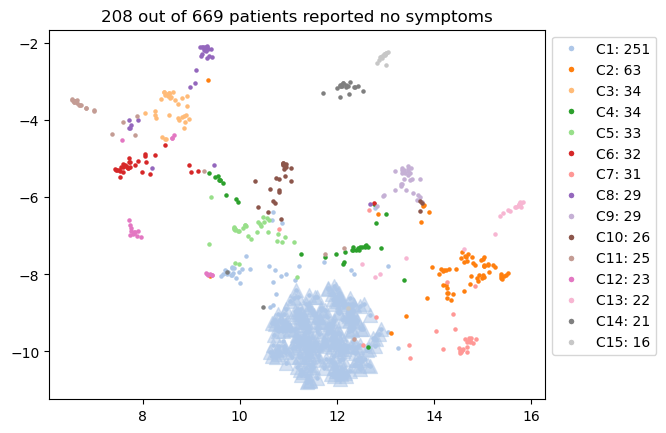

In [15]:
# Highlighting patients reporting 0 symptoms
title = "reported no symptoms"
patients = surveys[symptoms]
patients = list(patients[patients.sum(axis = 1) == 0.0].index)
plot_clusters(clusters, embedding, f"{len(patients)} out of {len(embedding)} patients {title}", colors, topic_proportions_, patients)

In [16]:
# Saving comorb proportions per cluster
conditions = surveys.copy()
conditions["cluster"] = ["C" + str(c) for c in clusters]
dictionary = dict(conditions["cluster"].value_counts())
df = pd.DataFrame({"cluster": dictionary.keys(), "total": dictionary.values()})
df = df.sort_values(["total", "cluster"], ascending = [False, True])
for condition in comorb_list: 
    patients = list(conditions[conditions[condition] == 1.0].index)
    dictionary = dict(conditions.iloc[patients, :]["cluster"].value_counts())
    df2 = pd.DataFrame({"cluster": list(dictionary.keys()), condition: list(dictionary.values())})
    df = df.merge(df2, on = "cluster", how = "outer")
    df["proportion_" + condition] = df[condition] / df["total"]
# df.to_csv("comorb_proportions_ucsf.csv", index = False)
df

,cluster,total,auto,proportion_auto,cancer,proportion_cancer,diab,proportion_diab,heart,proportion_heart,hiv,proportion_hiv,hosp,proportion_hosp,hyper,proportion_hyper,icu,proportion_icu,kidney,proportion_kidney,lung,proportion_lung,oxy,proportion_oxy,smk,proportion_smk,student,proportion_student,venti,proportion_venti
0,C1,251,15,0.059761,9.0,0.035857,21.0,0.083665,7.0,0.027888,43,0.171315,27.0,0.107570,35,0.139442,7.0,0.027888,3.0,0.011952,36,0.143426,17.0,0.067729,152,0.605578,139,0.553785,2.0,0.007968
1,C2,63,4,0.063492,4.0,0.063492,2.0,0.031746,1.0,0.015873,6,0.095238,2.0,0.031746,11,0.174603,2.0,0.031746,1.0,0.015873,10,0.158730,2.0,0.031746,36,0.571429,38,0.603175,1.0,0.015873
2,C3,34,4,0.117647,2.0,0.058824,NaN,NaN,NaN,NaN,2,0.058824,3.0,0.088235,5,0.147059,1.0,0.029412,NaN,NaN,8,0.235294,2.0,0.058824,23,0.676471,25,0.735294,1.0,0.029412
3,C4,34,2,0.058824,1.0,0.029412,NaN,NaN,NaN,NaN,10,0.294118,1.0,0.029412,5,0.147059,1.0,0.029412,NaN,NaN,2,0.058824,1.0,0.029412,22,0.647059,16,0.470588,NaN,NaN
4,C5,33,2,0.060606,3.0,0.090909,3.0,0.090909,NaN,NaN,4,0.121212,5.0,0.151515,6,0.181818,2.0,0.060606,1.0,0.030303,11,0.333333,3.0,0.090909,19,0.575758,20,0.606061,NaN,NaN
5,C6,32,9,0.281250,NaN,NaN,2.0,0.062500,NaN,NaN,3,0.093750,5.0,0.156250,2,0.062500,1.0,0.031250,NaN,NaN,4,0.125000,4.0,0.125000,19,0.593750,20,0.625000,NaN,NaN
6,C7,31,1,0.032258,1.0,0.032258,NaN,NaN,NaN,NaN,5,0.161290,4.0,0.129032,3,0.096774,2.0,0.064516,NaN,NaN,7,0.225806,4.0,0.129032,14,0.451613,13,0.419355,NaN,NaN
7,C8,29,2,0.068966,2.0,0.068966,2.0,0.068966,1.0,0.034483,2,0.068966,2.0,0.068966,7,0.241379,1.0,0.034483,NaN,NaN,9,0.310345,1.0,0.034483,21,0.724138,20,0.689655,1.0,0.034483
8,C9,29,5,0.172414,1.0,0.034483,3.0,0.103448,NaN,NaN,2,0.068966,1.0,0.034483,4,0.137931,1.0,0.034483,1.0,0.034483,6,0.206897,1.0,0.034483,15,0.517241,14,0.482759,1.0,0.034483
9,C10,26,1,0.038462,NaN,NaN,2.0,0.076923,2.0,0.076923,4,0.153846,2.0,0.076923,2,0.076923,1.0,0.038462,NaN,NaN,5,0.192308,1.0,0.038462,13,0.500000,9,0.346154,NaN,NaN


0.0    658
1.0      7
Name: kidney, dtype: int64


<Figure size 640x480 with 0 Axes>

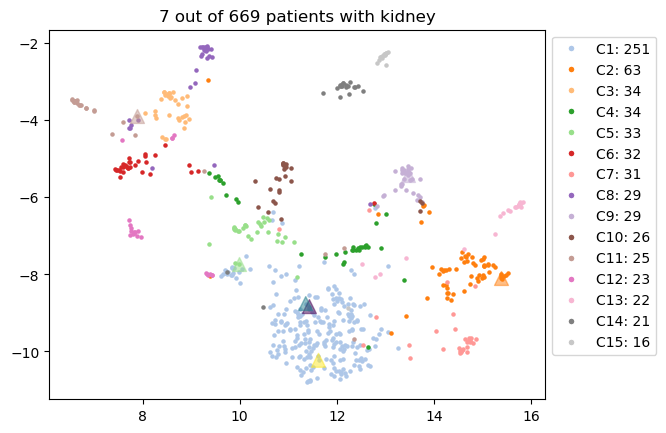

In [17]:
# Highlighting specific conditions
condition = "kidney"
title = condition
patients = list(surveys[surveys[condition] == 1.0].index)
print(surveys[condition].value_counts())
plot_clusters(clusters, embedding, f"{len(patients)} out of {len(embedding)} patients with {title}", colors, topic_proportions_, patients)

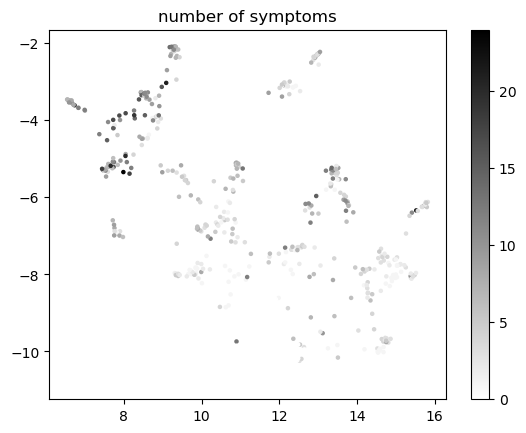

In [18]:
# Colored based on number of symptoms
plt.figure()
conditions = surveys[symptoms]
conditions["all"] = conditions.sum(axis = 1)
a = plt.scatter(embedding[:, 0], embedding[:, 1], c = conditions["all"], cmap = "binary", s = 5)
a = plt.title("number of symptoms")
a = plt.colorbar()

# Topic Proportions by Cluster

In [19]:
topic_proportions = pd.DataFrame(data['Theta_mean'].T)
topic_proportions.columns = ["T" + str(val) for val in range(1, topic_proportions.shape[1] + 1)]
topic_proportions_ = topic_proportions.copy()
topic_proportions_["cluster"] = clusters
topic_proportions_bycluster = topic_proportions_.groupby("cluster").mean()
topic_proportions_bycluster.index = ["C" + str(val) for val in topic_proportions_bycluster.index]
topic_proportions_bycluster = topic_proportions_bycluster.T
print(topic_proportions_bycluster.shape[0], "topics",  topic_proportions_bycluster.shape[1], "clusters", topic_proportions.shape[0], "patients")
# topic_proportions_bycluster = topic_proportions_bycluster.div(topic_proportions_bycluster.sum(axis=1), axis=0) #### row-wise normalizing
# topic_proportions_bycluster = topic_proportions_bycluster.div(topic_proportions_bycluster.sum(axis=0), axis=1) #### column-wise normalizing
print(topic_proportions_bycluster.sum(0)[:3])
print(topic_proportions_bycluster.sum(1)[:3])

22 topics 15 clusters 669 patients
C1     1.347344
C2     4.268830
C3    10.140961
dtype: float64
T1    5.112375
T2    3.798876
T3    7.659821
dtype: float64


trained_topic_model/PFA_trained_model_n669_k22.mat


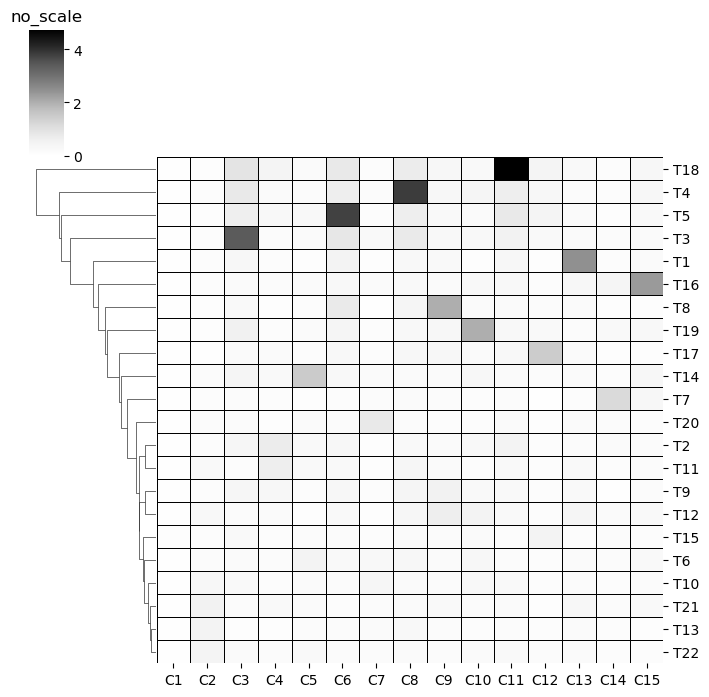

In [20]:
ax = sns.clustermap(topic_proportions_bycluster, vmin = 0, col_cluster = False, row_cluster = True, figsize = (7, 7), 
#                     standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.title("no_scale") # None
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=0, size = 10)
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


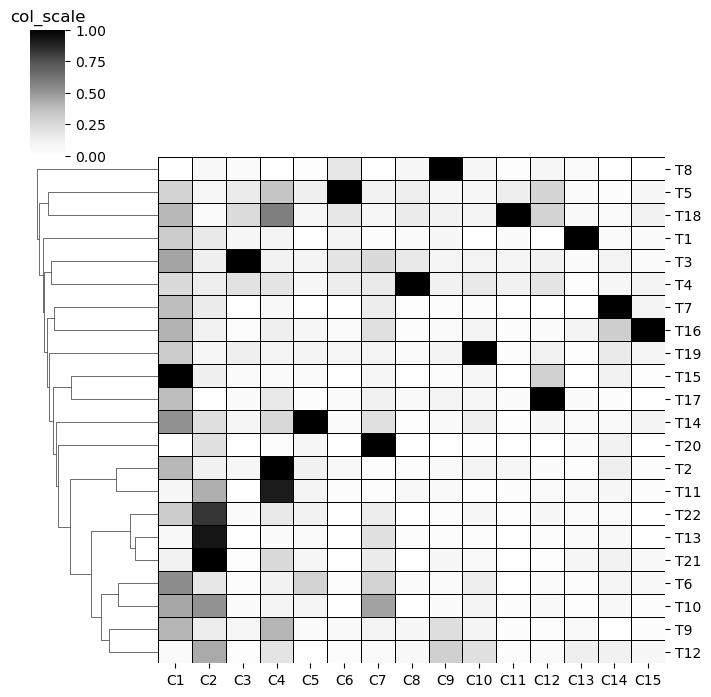

In [21]:
ax = sns.clustermap(topic_proportions_bycluster, vmin = 0, col_cluster = False, row_cluster = True, figsize = (7, 7), 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.title("col_scale") # 1
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=0, size = 10)
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


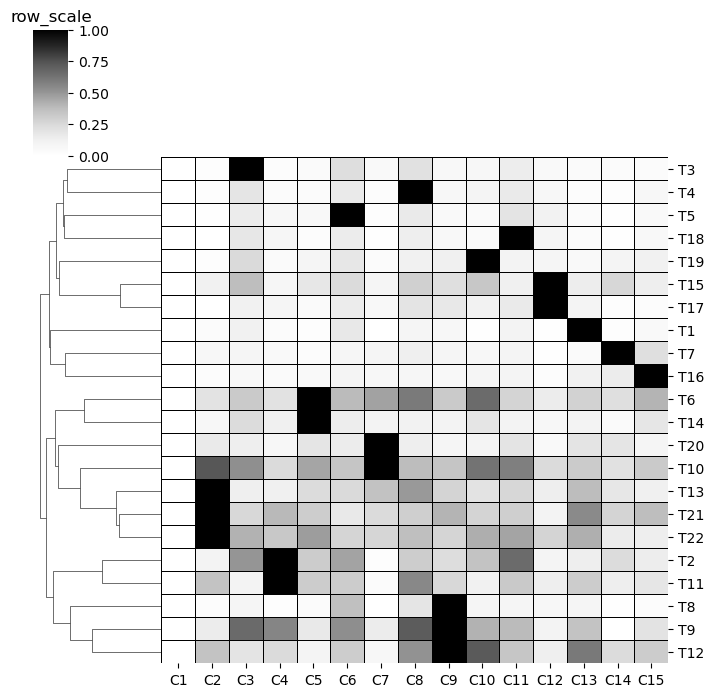

In [22]:
ax = sns.clustermap(topic_proportions_bycluster, vmin = 0, col_cluster = False, row_cluster = True, figsize = (7, 7), 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.title("row_scale") # 0
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=0, size = 10)
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

# Cluster by Symptom Heatmap

In [23]:
cluster_by_symptom = pd.DataFrame(np.dot(topic_matrix, topic_proportions_bycluster))
print(cluster_by_symptom.shape, "=", topic_matrix.shape, "x", topic_proportions_bycluster.shape)
cluster_by_symptom.index = topic_matrix.index
cluster_by_symptom.columns = ["C" + str(val) for val in range(1, cluster_by_symptom.shape[1] + 1)]
# cluster_by_symptom = cluster_by_symptom.div(cluster_by_symptom.sum(axis=1), axis=0) #### row-wise normalizing
# cluster_by_symptom = cluster_by_symptom.div(cluster_by_symptom.sum(axis=0), axis=1) #### column-wise normalizing
print(cluster_by_symptom.sum(0)[:3])
print(cluster_by_symptom.sum(1)[:3])

(32, 15) = (32, 22) x (22, 15)
C1     1.347344
C2     4.268830
C3    10.140961
dtype: float64
balan    3.026296
dizz     3.718905
faint    0.399195
dtype: float64


trained_topic_model/PFA_trained_model_n669_k22.mat


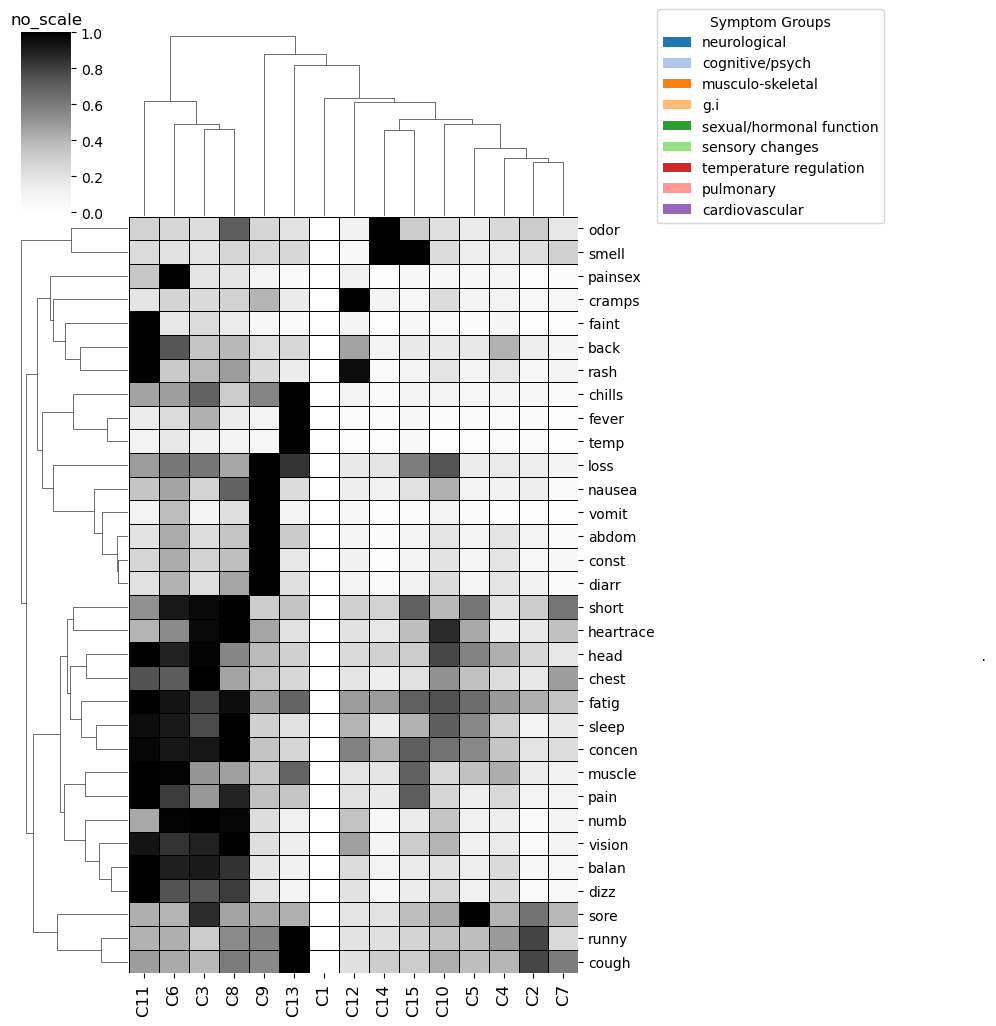

In [24]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = True, #row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("no_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


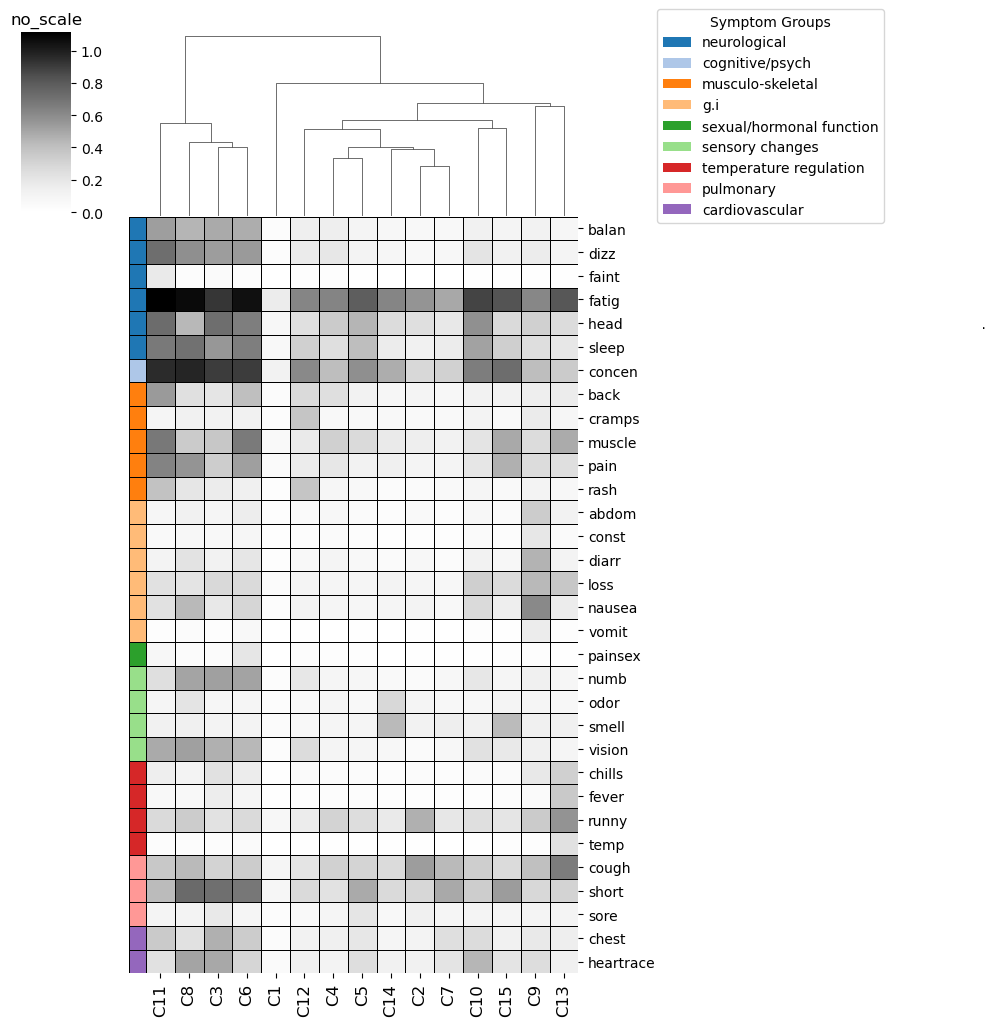

In [25]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
#                     standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("no_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


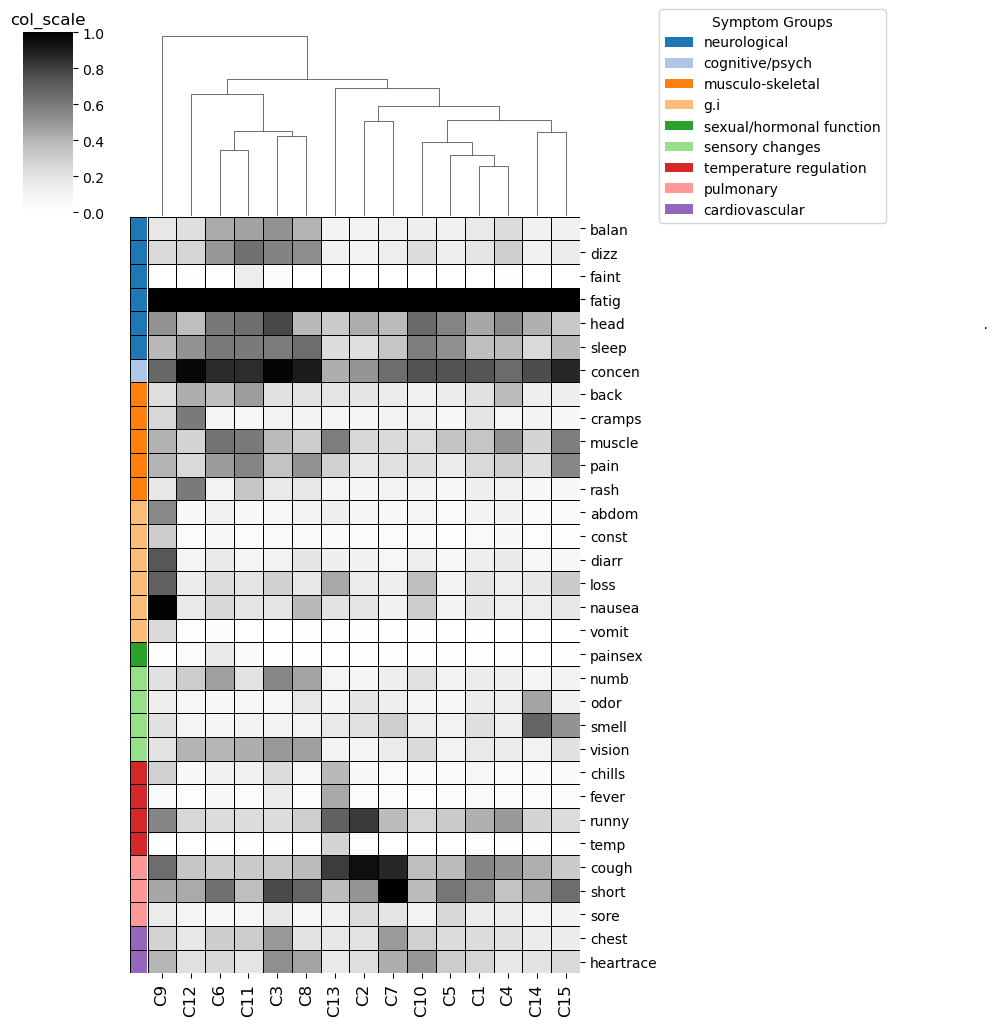

In [26]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


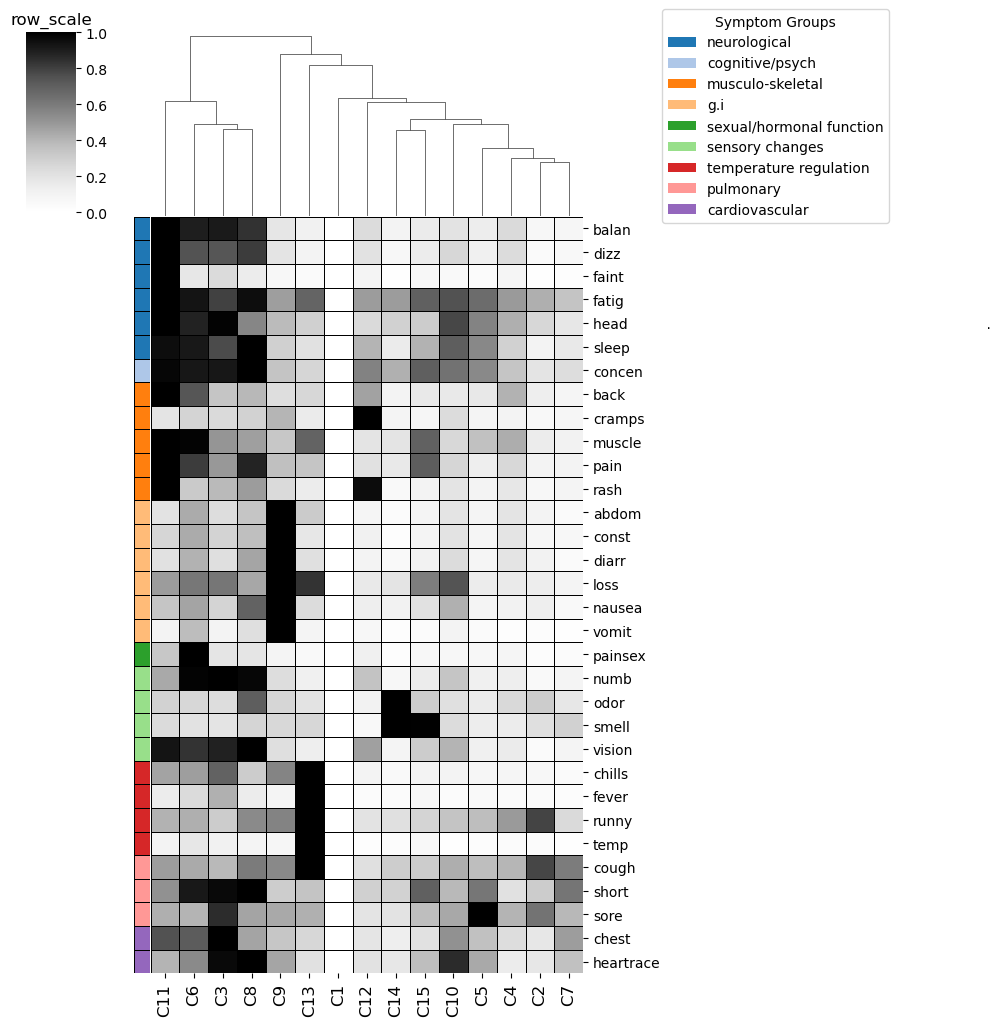

In [27]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


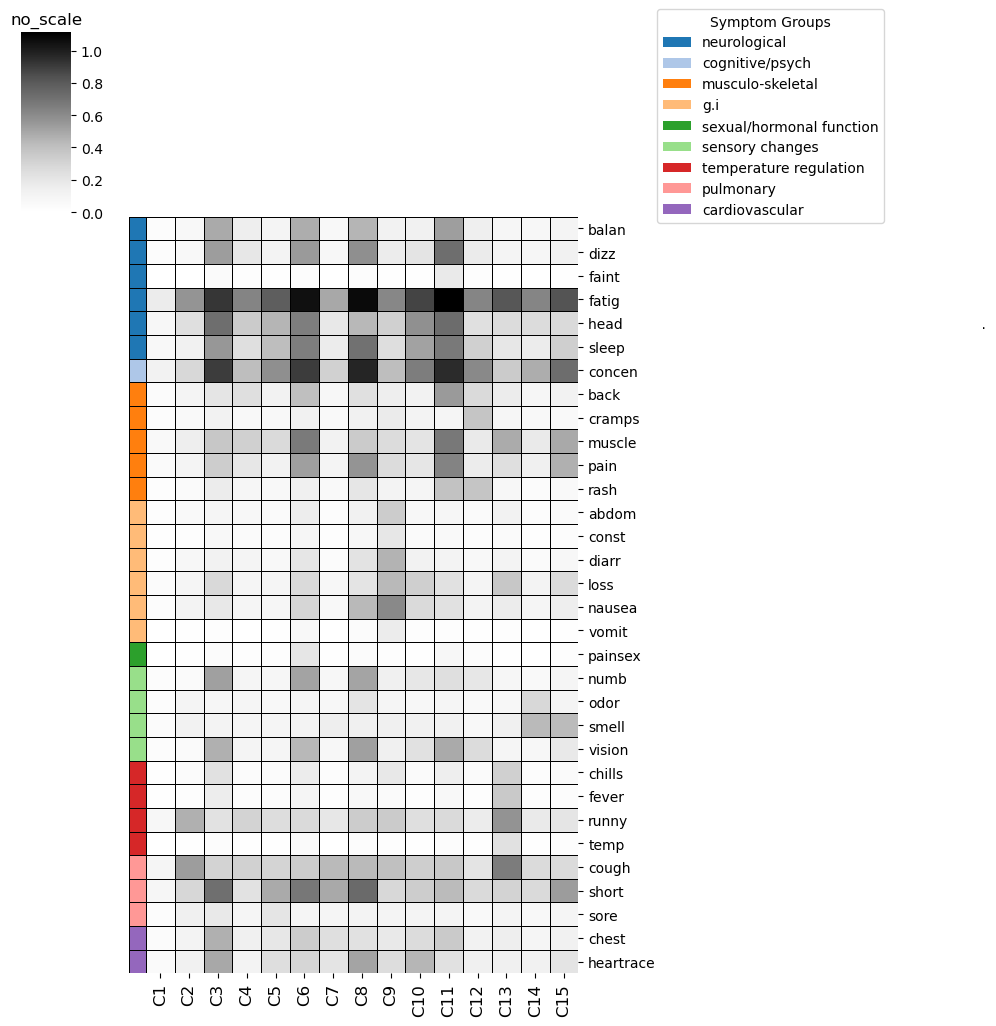

In [28]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
#                     standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("no_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


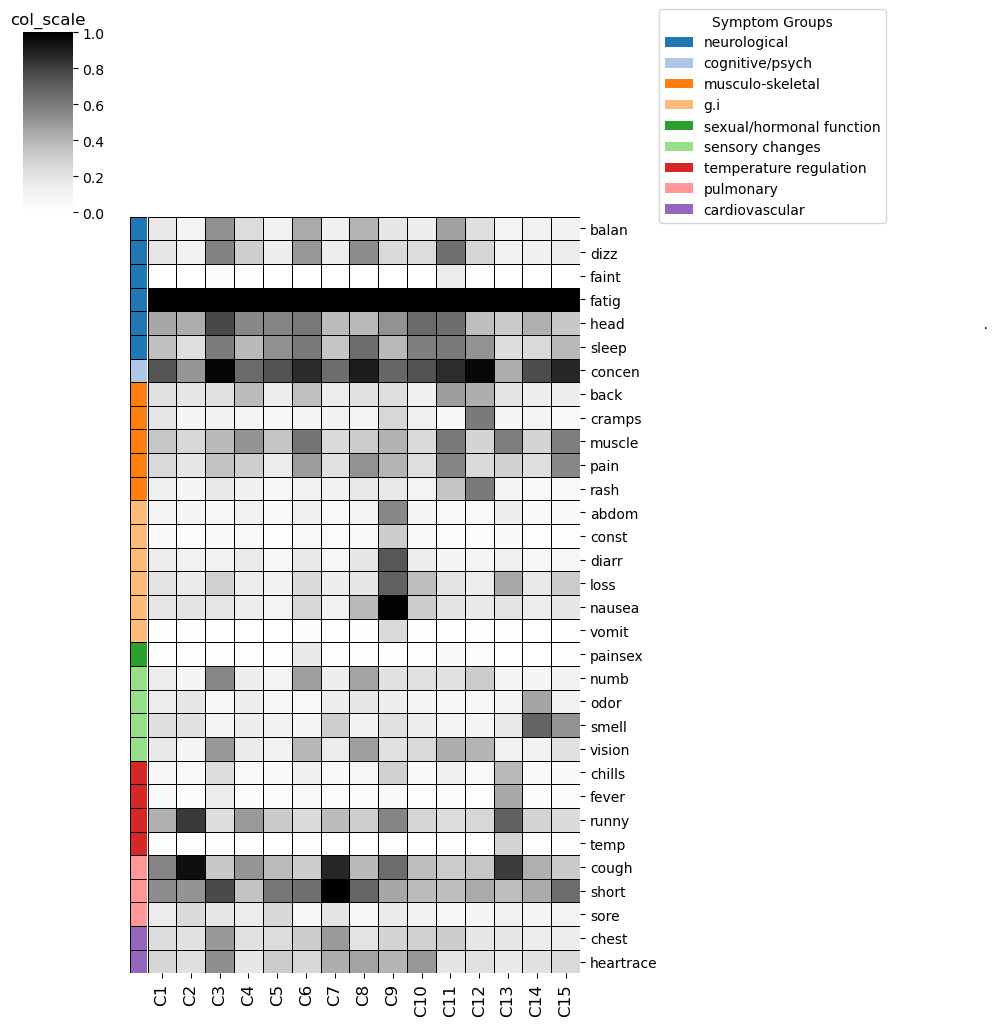

In [29]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model/PFA_trained_model_n669_k22.mat


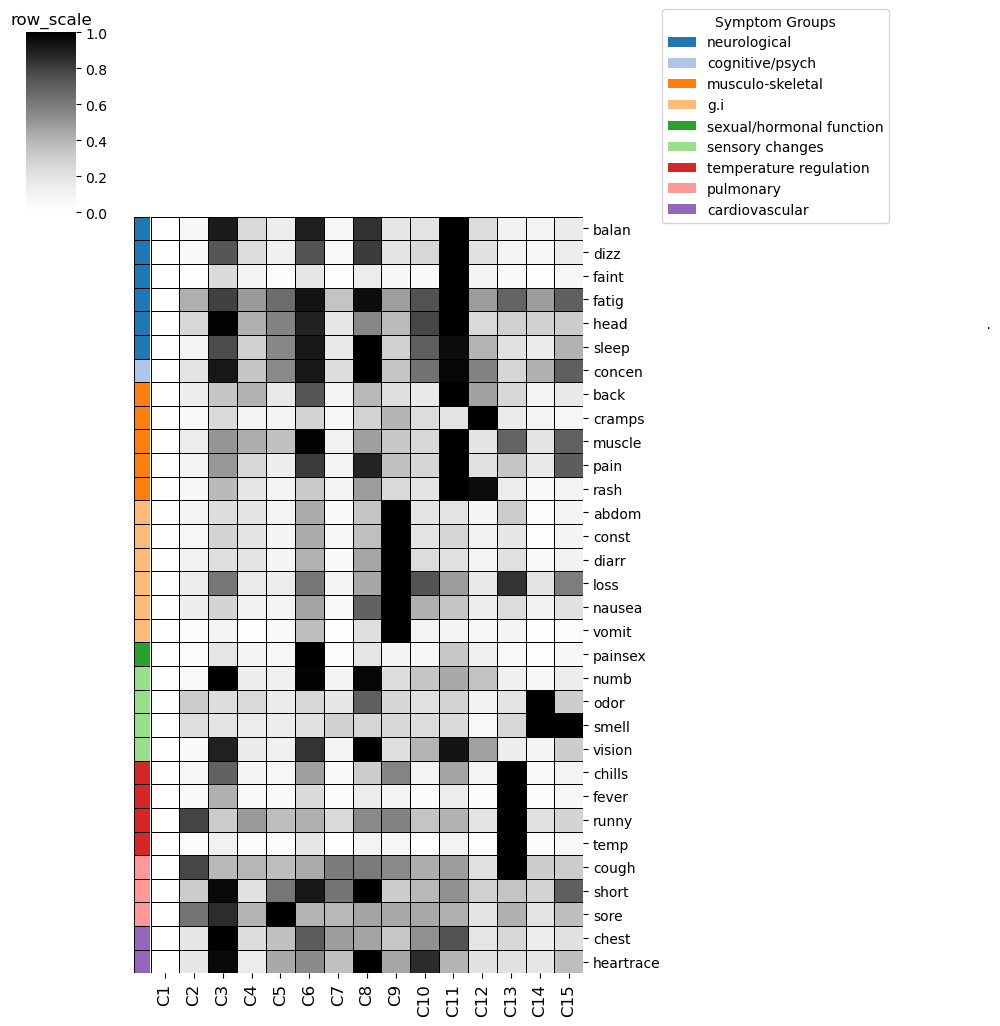

In [30]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

# Defining symptom severity groups

In [31]:
# Standardize the data
# https://github.com/mwaskom/seaborn/blob/86b5481ca47cb46d3b3e079a5ed9b9fb46e315ef/seaborn/matrix.py#L892
standardized = cluster_by_symptom.copy().T
subtract = standardized.min()
standardized = (standardized - subtract) / (standardized.max() - standardized.min())
standardized = standardized.T
standardized
# # Plotting to check same as sns.clustermap standard_scaling
# ax = sns.clustermap(standardized, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
# #                     standard_scale = 0, 
#                     xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
#                     cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15
balan,0.0,0.064375,0.913758,0.249519,0.144515,0.896917,0.075407,0.839401,0.181449,0.197405,1.000000,0.232976,0.119080,0.100858,0.155425
dizz,0.0,0.046235,0.733237,0.234131,0.122156,0.744677,0.060208,0.810033,0.190772,0.258014,1.000000,0.202884,0.105397,0.073605,0.146831
faint,0.0,0.010699,0.241375,0.085954,0.036175,0.177933,0.017836,0.152015,0.065949,0.050679,1.000000,0.092344,0.045060,0.015556,0.063434
fatig,0.0,0.420177,0.794213,0.486604,0.652109,0.932728,0.344374,0.956026,0.474466,0.749770,1.000000,0.482304,0.680162,0.483908,0.695859
head .,0.0,0.257860,0.986066,0.419733,0.569263,0.883846,0.176981,0.556469,0.379249,0.778091,1.000000,0.246607,0.289950,0.286409,0.307501
sleep,0.0,0.103995,0.766278,0.288418,0.549349,0.915964,0.167314,1.000000,0.290196,0.706494,0.955180,0.405618,0.205952,0.154569,0.413169
concen,0.0,0.191754,0.921005,0.343021,0.543782,0.919687,0.230028,1.000000,0.346649,0.628895,0.979201,0.571977,0.265515,0.417899,0.702549
back,0.0,0.139597,0.336548,0.412428,0.171557,0.731587,0.082611,0.393216,0.223491,0.165854,1.000000,0.461799,0.257946,0.103002,0.163428
cramps,0.0,0.057489,0.248640,0.102119,0.096217,0.272197,0.074318,0.281468,0.400333,0.237490,0.187927,1.000000,0.152800,0.096641,0.079091
muscle,0.0,0.147019,0.501123,0.429040,0.356210,0.985147,0.110761,0.470656,0.331748,0.257624,1.000000,0.194889,0.685829,0.190727,0.695202


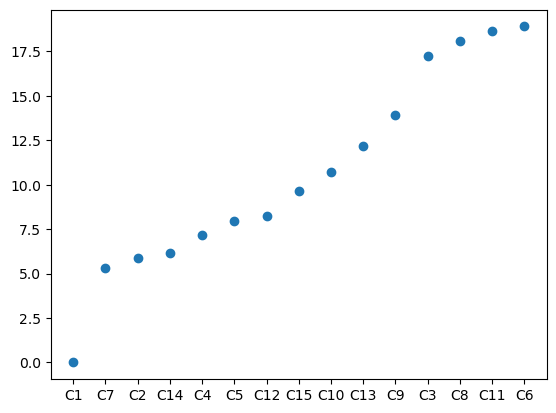

In [32]:
severity = pd.DataFrame(standardized.sum()).rename(columns = {0: "sum"}).sort_values("sum").reset_index()
a = plt.scatter(range(1, severity.shape[0] + 1), severity["sum"])
a = plt.xticks(range(1, severity.shape[0] + 1), severity["index"])

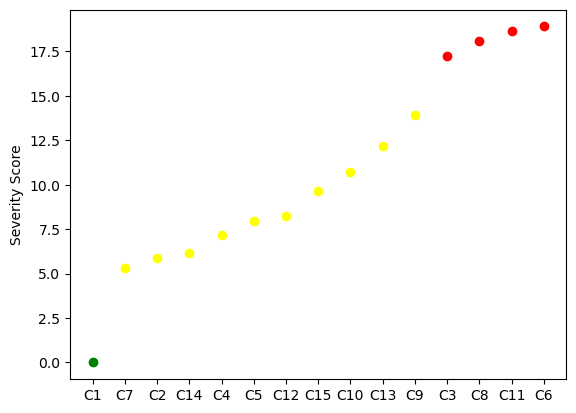

In [33]:
severity = pd.DataFrame(standardized.sum()).rename(columns = {0: "sum"}).sort_values("sum").reset_index()
severity["cluster"] = [int(val.replace("C", "")) for val in severity["index"]]
# Manually defining symptom groups based on plot above
colors_ = ["green"]*1
colors_.extend(["yellow"]*10)
colors_.extend(["red"]*4)
severity["color"] = colors_
for index, row in severity.iterrows(): 
    a = plt.scatter([index], row["sum"], c = row["color"])
a = plt.ylabel("Severity Score")
a = plt.xticks(range(0, severity.shape[0]), severity["index"])

In [34]:
# severity.to_csv(f"severity_ucsf_n{n}_{n_clusters}clusters.csv", index = False)
severity

,index,sum,cluster,color
0,C1,0.000000,1,green
1,C7,5.301489,7,yellow
2,C2,5.855775,2,yellow
3,C14,6.163947,14,yellow
4,C4,7.155718,4,yellow
5,C5,7.961321,5,yellow
6,C12,8.264181,12,yellow
7,C15,9.633212,15,yellow
8,C10,10.734800,10,yellow
9,C13,12.151816,13,yellow


In [35]:
dictionary = dict(zip(severity["cluster"], severity["color"]))
dictionary

{1: 'green',
 7: 'yellow',
 2: 'yellow',
 14: 'yellow',
 4: 'yellow',
 5: 'yellow',
 12: 'yellow',
 15: 'yellow',
 10: 'yellow',
 13: 'yellow',
 9: 'yellow',
 3: 'red',
 8: 'red',
 11: 'red',
 6: 'red'}

# Star Charts per Cluster

In [36]:
patient_by_symptom = pd.DataFrame(np.dot(topic_matrix, topic_proportions.T))
print(patient_by_symptom.shape,  "=", topic_matrix.shape, "+", topic_proportions.T.shape)
patient_by_symptom.index = topic_matrix.index
patient_by_symptom = patient_by_symptom.T
# patient_by_symptom = patient_by_symptom.div(patient_by_symptom.sum(axis=1), axis=0) #### row-wise normalizing
# patient_by_symptom = patient_by_symptom.div(patient_by_symptom.sum(axis=0), axis=1) #### column-wise normalizing
print(patient_by_symptom.sum(0)[:3])
print(patient_by_symptom.sum(1)[:3])
patient_by_symptom["cluster"] = clusters
patient_by_symptom
df = pd.DataFrame()
cluster_by_symptom_norm = cluster_by_symptom.div(cluster_by_symptom.sum(axis=1), axis=0) #### row-wise normalizing
for col in cluster_by_symptom_norm.columns: 
    subset = cluster_by_symptom_norm[col].sort_values(ascending = False)
    df[col + "_sym"] = subset.index
    df[col + "_pro"] = [round(val, 3) for val in list(subset)]
columns = list(filter(re.compile(".*sym").match, df.columns))
cluster_topsymptoms = df[columns].copy()
cluster_topsymptoms.columns = [col.split("_")[0] for col in cluster_topsymptoms.columns]
cluster_topsymptoms.head(6)

(32, 669) = (32, 22) + (22, 669)
balan     95.725794
dizz     115.689701
faint     11.683536
dtype: float64
0    1.010580
1    3.985255
2    2.907790
dtype: float64


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15
0,cramps,runny,numb,back,sore,painsex,cough,numb,vomit,heartrace,faint,cramps,temp,odor,smell
1,cough,cough,balan,runny,short,numb,short,vision,abdom,loss,rash,rash,fever,smell,pain
2,runny,sore,fever,muscle,head ...,balan,chest,dizz,const,head ...,dizz,back,chills,fatig,muscle
3,odor,odor,chills,sore,sleep,vomit,smell,balan,diarr,sleep,back,vision,runny,concen,loss
4,sore,smell,chest,cough,fatig,dizz,sore,nausea,nausea,nausea,balan,concen,cough,cough,short
5,smell,fatig,vision,head ...,heartrace,back,heartrace,heartrace,loss,chest,pain,numb,loss,head ...,concen


In [37]:
dictionary = {}
for index, row in patient_by_symptom.iterrows(): 
    cluster = "C" + str(int(row["cluster"]))
    symptoms_subset = list(cluster_topsymptoms[cluster])[:6]
    symptoms_subset.append(symptoms_subset[0])
    values = [row[s] for s in symptoms_subset]
    values.append(values[0])
    dictionary[index] = dict(r = values, theta = symptoms_subset)
print(len(dictionary))
# dictionary

669


In [38]:
# Adding sexes if provided
print(dict(surveys["sex"].value_counts()))
# count_sex = {"rgba(0,255,0,0.25)": 0, "rgba(0,0,255,0.25)": 0, "rgba(50,50,50,0.25)": 0}
# count_sex = {"rgb(0,255,0)": 0, "rgb(0,0,255)": 0, "rgb(50,50,50)": 0}
count_sex = {"rgb(0,0,255)": 0, "rgb(255,0,0)": 0, "rgb(50,50,50)": 0}
values = []
for val in surveys["sex"]: 
#     print(val)
    if str(val) == "1.0" or str(val) == "M": # M
        values.append(list(count_sex.keys())[0])
    elif str(val) == "2.0" or str(val) == "F": # F
        values.append(list(count_sex.keys())[1])
    else: # else
        values.append(list(count_sex.keys())[2])
sexes = values[:]
print(len(sexes), Counter(sexes))

{'F': 365, 'M': 304}
669 Counter({'rgb(255,0,0)': 365, 'rgb(0,0,255)': 304})


In [39]:
def star_chart_per_patient(cluster): 
    scatterpolars = []
#     count_sex = {"rgba(0,255,0,0.75)": 0, "rgba(0,0,255,0.75)": 0, "rgba(50,50,50,0.25)": 0}
#     count_sex = {"rgb(0,255,0)": 0, "rgb(0,0,255)": 0, "rgb(50,50,50)": 0}
    count_sex = {"rgb(0,0,255)": 0, "rgb(255,0,0)": 0, "rgb(50,50,50)": 0}
    for i in list(patient_by_symptom[patient_by_symptom["cluster"] == cluster].index)[:]: 
        scatterpolars.append(go.Scatterpolar(dictionary[i], # fill = "toself", fillcolor = sexes[i], 
                                             mode = "lines",            
                                             name = "Patient" + str(i+1), 
                                             line_color = sexes[i], 
#                                              line = {"opacity": 0.25}, 
#                                              line_color = "rgba(100,25,25,0.25)", 
                                            ))
        count_sex[sexes[i]] += 1
    fig = go.Figure(data = scatterpolars)
    fig.update_traces(opacity = 0.25)
    # fig.update_polars(radialaxis=dict(range=[0, 1]))
    count_sex_str = str(count_sex).replace(list(count_sex.keys())[0], "M (blue)").replace(list(count_sex.keys())[1], "F (red)").replace(list(count_sex.keys())[2], "nan (gray)")
#     count_sex_str = ""
    fig.update_layout(title = ".\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\tCluster" + str(cluster) + ": " + str(len(scatterpolars)) + " patients " + count_sex_str)
    return fig

star_chart_per_patient(1)

In [40]:
star_chart_per_patient(2)

In [41]:
star_chart_per_patient(3)

In [42]:
star_chart_per_patient(4)

In [43]:
star_chart_per_patient(5)

In [44]:
star_chart_per_patient(6)

In [45]:
star_chart_per_patient(7)

In [46]:
star_chart_per_patient(8)

In [47]:
star_chart_per_patient(9)

In [48]:
star_chart_per_patient(10)

In [49]:
star_chart_per_patient(11)

In [50]:
star_chart_per_patient(12)

In [51]:
star_chart_per_patient(13)

In [52]:
star_chart_per_patient(14)

In [53]:
star_chart_per_patient(15)

# Star Charts Median

In [54]:
def star_chart_median(cluster): 
    dictionary = {}
    symptoms_subset = list(cluster_topsymptoms["C" + str(cluster)])[:6]
    cluster_subset = patient_by_symptom[patient_by_symptom["cluster"] == cluster]
    cluster_subset["sex"] = surveys["sex"]
    for sex in ["F", "M"]: 
        cluster_sex_subset = cluster_subset[cluster_subset["sex"] == sex]
        cluster_sex_subset = cluster_sex_subset.median()[symptoms_subset]
        cluster_sex_subset = dict(cluster_sex_subset)
        key = f"{sex} (in cluster)"
        dictionary[key] = dict(r = list(cluster_sex_subset.values()), theta = list(cluster_sex_subset.keys()))
        dictionary[key]["r"].append(dictionary[key]["r"][0])
        dictionary[key]["theta"].append(dictionary[key]["theta"][0])
    cluster_subset = patient_by_symptom[patient_by_symptom["cluster"] != cluster]
    cluster_subset["sex"] = surveys["sex"]
    for sex in ["F", "M"]: 
        cluster_sex_subset = cluster_subset[cluster_subset["sex"] == sex]
        cluster_sex_subset = cluster_sex_subset.median()[symptoms_subset]
        cluster_sex_subset = dict(cluster_sex_subset)
        key = f"{sex} (global)"
        dictionary[key] = dict(r = list(cluster_sex_subset.values()), theta = list(cluster_sex_subset.keys()))
        dictionary[key]["r"].append(dictionary[key]["r"][0])
        dictionary[key]["theta"].append(dictionary[key]["theta"][0])

    scatterpolars = []
    scatterpolars.append(go.Scatterpolar(dictionary["F (in cluster)"], mode = "lines", 
                                         name = "F (in cluster)", line_color = "rgba(255,0,0,0.25)", ))
    scatterpolars.append(go.Scatterpolar(dictionary["M (in cluster)"], mode = "lines", 
                                         name = "M (in cluster)", line_color = "rgba(0,0,255,0.25)", ))
    scatterpolars.append(go.Scatterpolar(dictionary["F (global)"], mode = "lines", line = dict(dash = "dash"), 
                                         name = "F (global)", line_color = "rgba(255,0,0,0.25)", ))
    scatterpolars.append(go.Scatterpolar(dictionary["M (global)"], mode = "lines", line = dict(dash = "dash"), 
                                         name = "M (global)", line_color = "rgba(0,0,255,0.25)", ))
    fig = go.Figure(data = scatterpolars)
    count_sex_str = ""
    fig.update_layout(title = ".\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\tCluster" + str(cluster) + ": " + str(patient_by_symptom[patient_by_symptom["cluster"] == cluster].shape[0]) + " patients " + count_sex_str)
    return fig
star_chart_median(1)

In [55]:
star_chart_median(2)

In [56]:
star_chart_median(3)

In [57]:
star_chart_median(4)

In [58]:
star_chart_median(5)

In [59]:
star_chart_median(6)

In [60]:
star_chart_median(7)

In [61]:
star_chart_median(8)

In [62]:
star_chart_median(9)

In [63]:
star_chart_median(10)

In [64]:
star_chart_median(11)

In [65]:
star_chart_median(12)

In [66]:
star_chart_median(13)

In [67]:
star_chart_median(14)

In [68]:
star_chart_median(15)

# Getting endotypes

In [69]:
cluster_topsymptoms = cluster_topsymptoms.head(6)
cluster_topsymptoms_dict = {}
for col in cluster_topsymptoms.columns: 
    values = list(cluster_topsymptoms[col])
    values = ["head" if "head" in val else val for val in values]
    cluster_topsymptoms_dict[int(col.replace("C", ""))] = values
cluster_topsymptoms_dict

{1: ['cramps', 'cough', 'runny', 'odor', 'sore', 'smell'],
 2: ['runny', 'cough', 'sore', 'odor', 'smell', 'fatig'],
 3: ['numb', 'balan', 'fever', 'chills', 'chest', 'vision'],
 4: ['back', 'runny', 'muscle', 'sore', 'cough', 'head'],
 5: ['sore', 'short', 'head', 'sleep', 'fatig', 'heartrace'],
 6: ['painsex', 'numb', 'balan', 'vomit', 'dizz', 'back'],
 7: ['cough', 'short', 'chest', 'smell', 'sore', 'heartrace'],
 8: ['numb', 'vision', 'dizz', 'balan', 'nausea', 'heartrace'],
 9: ['vomit', 'abdom', 'const', 'diarr', 'nausea', 'loss'],
 10: ['heartrace', 'loss', 'head', 'sleep', 'nausea', 'chest'],
 11: ['faint', 'rash', 'dizz', 'back', 'balan', 'pain'],
 12: ['cramps', 'rash', 'back', 'vision', 'concen', 'numb'],
 13: ['temp', 'fever', 'chills', 'runny', 'cough', 'loss'],
 14: ['odor', 'smell', 'fatig', 'concen', 'cough', 'head'],
 15: ['smell', 'pain', 'muscle', 'loss', 'short', 'concen']}

In [70]:
color_mapping_rev = dict(zip(color_mapping.values(), color_mapping.keys()))
cluster_toporgans_dict = {}
for cluster in cluster_topsymptoms_dict.keys(): 
    toporgans = {}
    for sym in cluster_topsymptoms_dict[cluster]: 
        if sym == "head": sym = 'head                                                                                  .'
        val = color_mapping_rev[symptoms_ordered_colors[symptoms_ordered.index(sym)]]
        if val not in toporgans: toporgans[val] = 1
        else: toporgans[val] += 1
        if len(toporgans) == 3: break
    cluster_toporgans_dict[cluster] = list(np.unique(list(toporgans.keys())))
cluster_toporgans_dict

{1: ['musculo-skeletal', 'pulmonary', 'temperature regulation'],
 2: ['pulmonary', 'sensory changes', 'temperature regulation'],
 3: ['neurological', 'sensory changes', 'temperature regulation'],
 4: ['musculo-skeletal', 'pulmonary', 'temperature regulation'],
 5: ['cardiovascular', 'neurological', 'pulmonary'],
 6: ['neurological', 'sensory changes', 'sexual/hormonal function'],
 7: ['cardiovascular', 'pulmonary', 'sensory changes'],
 8: ['g.i', 'neurological', 'sensory changes'],
 9: ['g.i'],
 10: ['cardiovascular', 'g.i', 'neurological'],
 11: ['musculo-skeletal', 'neurological'],
 12: ['cognitive/psych', 'musculo-skeletal', 'sensory changes'],
 13: ['g.i', 'pulmonary', 'temperature regulation'],
 14: ['cognitive/psych', 'neurological', 'sensory changes'],
 15: ['g.i', 'musculo-skeletal', 'sensory changes']}

trained_topic_model/PFA_trained_model_n669_k22.mat


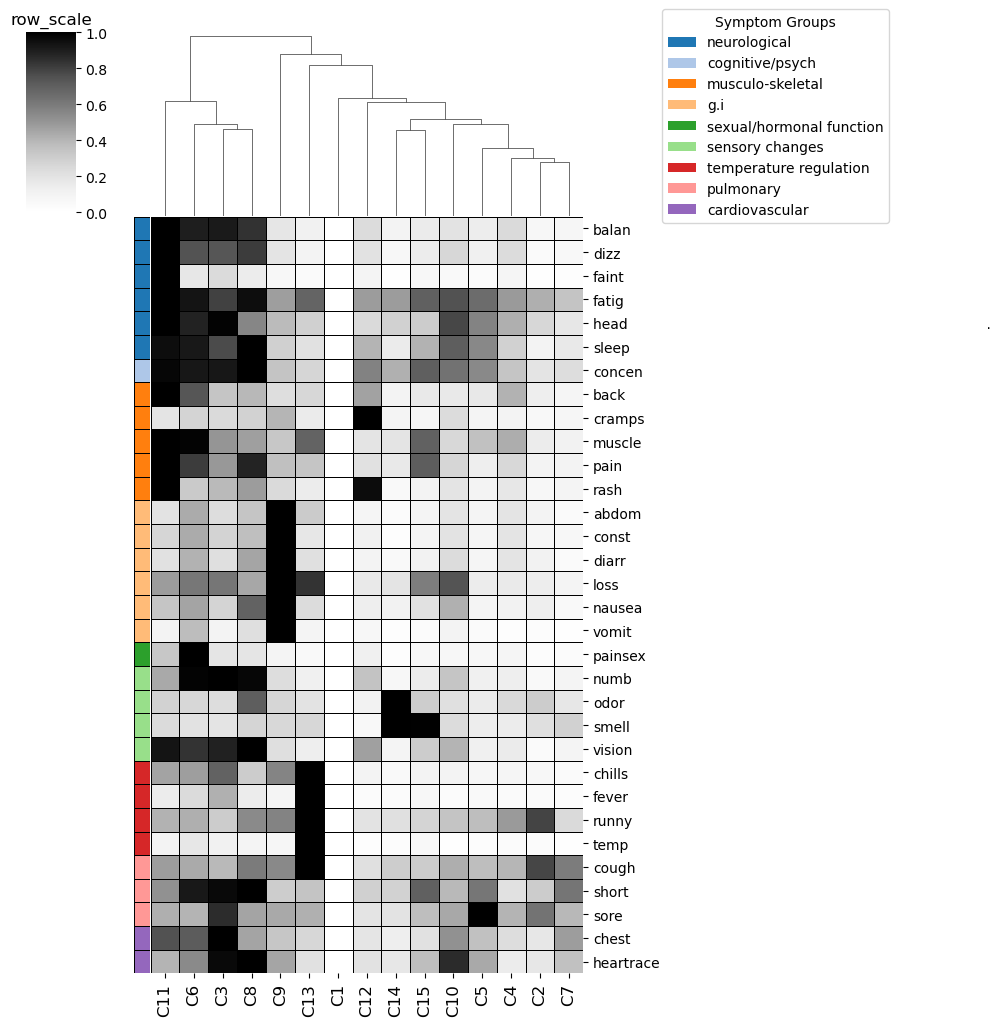

In [71]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

In [72]:
# printing top organ systems in cluster order
for key in [11, 6, 3, 8, 9, 13, 1, 12, 14, 15, 10, 5, 4, 2, 7]: 
    print(key, cluster_toporgans_dict[key])

11 ['musculo-skeletal', 'neurological']
6 ['neurological', 'sensory changes', 'sexual/hormonal function']
3 ['neurological', 'sensory changes', 'temperature regulation']
8 ['g.i', 'neurological', 'sensory changes']
9 ['g.i']
13 ['g.i', 'pulmonary', 'temperature regulation']
1 ['musculo-skeletal', 'pulmonary', 'temperature regulation']
12 ['cognitive/psych', 'musculo-skeletal', 'sensory changes']
14 ['cognitive/psych', 'neurological', 'sensory changes']
15 ['g.i', 'musculo-skeletal', 'sensory changes']
10 ['cardiovascular', 'g.i', 'neurological']
5 ['cardiovascular', 'neurological', 'pulmonary']
4 ['musculo-skeletal', 'pulmonary', 'temperature regulation']
2 ['pulmonary', 'sensory changes', 'temperature regulation']
7 ['cardiovascular', 'pulmonary', 'sensory changes']


In [73]:
endo_dict = {1:0, 2:1, 3:2, 4:1, 5:1, 6:2, 7:1, 8:2, 9:3, 10:1, 11:4, 12:5, 13:3, 14:5, 15:5} # ucsf_n669

In [74]:
severity

,index,sum,cluster,color
0,C1,0.000000,1,green
1,C7,5.301489,7,yellow
2,C2,5.855775,2,yellow
3,C14,6.163947,14,yellow
4,C4,7.155718,4,yellow
5,C5,7.961321,5,yellow
6,C12,8.264181,12,yellow
7,C15,9.633212,15,yellow
8,C10,10.734800,10,yellow
9,C13,12.151816,13,yellow


# Final cluster assignments

In [75]:
surveys = pd.read_csv("data_cleaned/preprocessed_n669_to1.csv")
# surveys = surveys.rename(columns = {"head": 'head                                                                                  .'})
patients = surveys.copy()
patients["cluster"] = clusters
dictionary = dict(zip(severity["cluster"], severity["color"]))
patients["severity"] = [dictionary[val] for val in patients["cluster"]]
dictionary = {"green": "mild", "yellow": "moderate", "red": "severe"}
patients["severity"] = [dictionary[val] for val in patients["severity"]]
dictionary = dict(zip(severity["cluster"], severity["sum"]))
patients["severity_score"] = [dictionary[val] for val in patients["cluster"]]
patients["top6symptoms"] = [cluster_topsymptoms_dict[val] for val in patients["cluster"]]
patients["top3organs"] = [cluster_toporgans_dict[val] for val in patients["cluster"]]
patients["endotype"] = ["E" + str(endo_dict[val]) for val in patients["cluster"]]
patients["subject_id"] = [1118, 1123, 1193, 1194, 1387, 1560, 1626, 2080, 2143, 2193, 2226, 2251, 2259, 2286, 2377, 2458, 2523, 2525, 2529, 2580, 2594, 2613, 2680, 2786, 2835, 2893, 2942, 3164, 3675, 3736, 4501, 4502, 4503, 4505, 4506, 4508, 4510, 4513, 4514, 4515, 4519, 4521, 4525, 4530, 4531, 4532, 4533, 4534, 4535, 4536, 4538, 4540, 4541, 4542, 4546, 4547, 4549, 4551, 4552, 4555, 4558, 4560, 4562, 4564, 4567, 4572, 4573, 4576, 4577, 4591, 4593, 4612, 4649, 4654, 4655, 4727, 4738, 4833, 5018, 5019, 5020, 5021, 5022, 5023, 5024, 5025, 5026, 5027, 5028, 5029, 5030, 5031, 5032, 5033, 5034, 5035, 5036, 5037, 5039, 5040, 5041, 5042, 5043, 5044, 5045, 5046, 5047, 5048, 5049, 5050, 5051, 5052, 5053, 5054, 5055, 5056, 5057, 5058, 5059, 5060, 5061, 5062, 5063, 5064, 5065, 5066, 5068, 5069, 5071, 5072, 5073, 5074, 5075, 5076, 5077, 5079, 5080, 5081, 5082, 5083, 5084, 5086, 5087, 5088, 5089, 5090, 5091, 5092, 5095, 5096, 5097, 5098, 5100, 5102, 5103, 5104, 5105, 5106, 5107, 5109, 5111, 5112, 5114, 5117, 5118, 5120, 5121, 5122, 5123, 5125, 5126, 5128, 5129, 5130, 5132, 5133, 5134, 5135, 5136, 5138, 5139, 5140, 5141, 5142, 5143, 5144, 5145, 5146, 5147, 5148, 5149, 5151, 5182, 5186, 5188, 5189, 5190, 5191, 5200, 5201, 5202, 5203, 5204, 5205, 5206, 5207, 5208, 5209, 5211, 5213, 5214, 5215, 5216, 5217, 5218, 5219, 5221, 5222, 5223, 5224, 5225, 5226, 5227, 5229, 5230, 5231, 5233, 5235, 5236, 5237, 5238, 5240, 5241, 5242, 5244, 5247, 5249, 5250, 5251, 5253, 5254, 5255, 5256, 5257, 5258, 5259, 5260, 5261, 5264, 5265, 5266, 5267, 5268, 5269, 5270, 5271, 5272, 5273, 5274, 5275, 5277, 5278, 5279, 5280, 5282, 5283, 5284, 5285, 5287, 5288, 5289, 5291, 5292, 5293, 5294, 5296, 5297, 5298, 5299, 5300, 5301, 5302, 5306, 5308, 5310, 5311, 5312, 5313, 5314, 5315, 5316, 5317, 5318, 5319, 5321, 5322, 5323, 5324, 5325, 5326, 5327, 5328, 5330, 5331, 5332, 5333, 5334, 5335, 5336, 5337, 5338, 5339, 5340, 5341, 5342, 5343, 5344, 5345, 5346, 5347, 5348, 5349, 5350, 5351, 5352, 5353, 5354, 5356, 5357, 5358, 5360, 5361, 5363, 5364, 5365, 5366, 5367, 5368, 5369, 5370, 5371, 5372, 5373, 5374, 5375, 5376, 5377, 5378, 5379, 5381, 5382, 5383, 5386, 5387, 5389, 5390, 5392, 5393, 5394, 5395, 5396, 5397, 5398, 5400, 5402, 5403, 5404, 5405, 5406, 5408, 5409, 5410, 5411, 5412, 5414, 5415, 5520, 5521, 5522, 5524, 5525, 5526, 5527, 5528, 5532, 5624, 5625, 5626, 5627, 5629, 5630, 5631, 5633, 5634, 5635, 5637, 5638, 5639, 5640, 5641, 5642, 5643, 5644, 5645, 5646, 5647, 5648, 5649, 5650, 5651, 5652, 5656, 5658, 5659, 5660, 5663, 5665, 5669, 5672, 5700, 5701, 5703, 5704, 5705, 5706, 5707, 5708, 5709, 5711, 5712, 5713, 5715, 5716, 5717, 5718, 5719, 5720, 5721, 5723, 5724, 5725, 5726, 5727, 5728, 5729, 5730, 5733, 5734, 5735, 5736, 5737, 5738, 5739, 5740, 5741, 5742, 5743, 5744, 5745, 5746, 5747, 5748, 5749, 5750, 5753, 5755, 5756, 5757, 5758, 5759, 5760, 5761, 5762, 5763, 5764, 5765, 5766, 5767, 5768, 5769, 5770, 5771, 5773, 5775, 5776, 5777, 5778, 5779, 5780, 5781, 5782, 5783, 5784, 5785, 5786, 5787, 5788, 5790, 5791, 5792, 5793, 5794, 5795, 5796, 5799, 5800, 5801, 5802, 5805, 5806, 5807, 5808, 5809, 5810, 5811, 5813, 5815, 5817, 5819, 5820, 5821, 5823, 5824, 5826, 5827, 5828, 5830, 5831, 5832, 5833, 5835, 5836, 5838, 5839, 5840, 5841, 5842, 5845, 5846, 5847, 5848, 5849, 5850, 5851, 5852, 5853, 5854, 5855, 5856, 5857, 5858, 5859, 5860, 5862, 5864, 5865, 5866, 5871, 5872, 5873, 5874, 5875, 5876, 5877, 5879, 5880, 5881, 5882, 5883, 5884, 5885, 5888, 5889, 5890, 5892, 5893, 5895, 5897, 5899, 5900, 5901, 5902, 5903, 5904, 5905, 5907, 5908, 5909, 5912, 5913, 5914, 5915, 5916, 5919, 5920, 5921, 5922, 5923, 5924, 5925, 5926, 5927, 5928, 5929, 5930, 5931, 5932, 5933, 5934, 5935, 5936, 5938, 5939, 5940, 5941, 5942, 5943, 5944, 5945, 5947, 5948, 5949, 5950, 5951, 5952, 5953, 5954, 5955, 5957, 5958, 5959, 5961, 5962, 5963, 5964, 5966, 5967, 5968, 5970, 5973, 5974, 5975, 5977, 5978, 5979, 5980, 5983, 5984, 5985, 5986, 5987, 5988, 5989, 5990, 5991, 5992, 5993, 5994, 5995, 5998, 5999, 6014, 6582, 6622, 8007, 8011, 8012, 8018, 8019]
columns = ["subject_id", 'sex', 'cluster', 'endotype', 'severity', 'severity_score', 'top6symptoms', 'top3organs']
#, 'auto', 'cancer', 'diab', 'heart', 'hiv', 'hosp', 'hyper', 'icu', 'kidney', 'lung', 'oxy', 'smk', 'student', 'venti', 'day', 'abdom', 'back', 'balan', 'chest', 'chills', 'concen', 'const', 'cough', 'cramps', 'diarr', 'dizz', 'faint', 'fatig', 'fever', 'head                                                                                  .', 'heartrace', 'loss', 'muscle', 'nausea', 'numb', 'odor', 'pain', 'painsex', 'rash', 'runny', 'short', 'sleep', 'smell', 'sore', 'temp', 'vision', 'vomit']
patients = patients[columns]
patients.columns = ["Subject_ID", "Sex", "Cluster_ID", "Endotype_ID (defined by organ systems involved)", 
                    "Severity_Group (predicted by ML)", "severity_score", "Top6_signature_symptoms", "Top3_organ_systems"]
# patients.to_csv(f"cluster_assignments_ucsf_n{n}_{number_of_topics}topics_{n_clusters}clusters_v3.csv", index = False)
patients

,Subject_ID,Sex,Cluster_ID,Endotype_ID (defined by organ systems involved),Severity_Group (predicted by ML),severity_score,Top6_signature_symptoms,Top3_organ_systems
0,1118,M,1,E0,mild,0.000000,"[cramps, cough, runny, odor, sore, smell]","[musculo-skeletal, pulmonary, temperature regu..."
1,1123,M,2,E1,moderate,5.855775,"[runny, cough, sore, odor, smell, fatig]","[pulmonary, sensory changes, temperature regul..."
2,1193,M,4,E1,moderate,7.155718,"[back, runny, muscle, sore, cough, head]","[musculo-skeletal, pulmonary, temperature regu..."
3,1194,M,1,E0,mild,0.000000,"[cramps, cough, runny, odor, sore, smell]","[musculo-skeletal, pulmonary, temperature regu..."
4,1387,M,1,E0,mild,0.000000,"[cramps, cough, runny, odor, sore, smell]","[musculo-skeletal, pulmonary, temperature regu..."
...,...,...,...,...,...,...,...,...
664,8007,M,2,E1,moderate,5.855775,"[runny, cough, sore, odor, smell, fatig]","[pulmonary, sensory changes, temperature regul..."
665,8011,M,6,E2,severe,18.898101,"[painsex, numb, balan, vomit, dizz, back]","[neurological, sensory changes, sexual/hormona..."
666,8012,M,1,E0,mild,0.000000,"[cramps, cough, runny, odor, sore, smell]","[musculo-skeletal, pulmonary, temperature regu..."
667,8018,M,12,E5,moderate,8.264181,"[cramps, rash, back, vision, concen, numb]","[cognitive/psych, musculo-skeletal, sensory ch..."


In [76]:
)

SyntaxError: unmatched ')' (687023194.py, line 1)

In [ ]:
nan = np.nan
values = [nan, 85.0, 95.0, nan, nan, 60.0, 75.0, 85.0, 95.0, 75.0, 70.0, 95.0, 93.0, 80.0, 90.0, 50.0, 75.0, nan, 90.0, 85.0, 85.0, 70.0, 100.0, 77.5, 75.0, 75.0, 85.0, 70.0, 85.0, 90.0, 90.0, nan, 75.0, 75.0, 80.0, nan, 100.0, 50.0, nan, 95.0, 50.0, 75.0, 65.0, 75.0, 80.0, 85.0, 60.0, 55.0, 80.0, 60.0, 75.0, 40.0, 70.0, 40.0, 40.0, 60.0, 60.0, 70.0, 75.0, 90.0, 75.0, 70.0, 80.0, 62.0, 70.0, 75.0, 99.0, 60.0, 85.0, 95.0, 98.0, 70.0, 80.0, 86.0, 90.0, 90.0, 60.0, 80.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 65.0, nan, nan, nan, nan, nan, nan, nan, nan, nan, 65.0, 90.0, nan, nan, nan, 65.0, nan, nan, 80.0, nan, nan, nan, nan, nan, nan, nan, nan, 10.0, nan, 90.0, 70.0, 70.0, 70.0, 80.0, 100.0, 80.0, nan, 90.0, 45.0, nan, nan, 80.0, 80.0, 90.0, 90.0, 95.0, 88.0, 90.0, 65.0, 95.0, 75.0, 85.0, 70.0, 90.0, 85.0, 100.0, 50.0, 95.0, 95.0, 65.0, 75.0, 90.0, 85.0, 100.0, 80.0, 100.0, 100.0, 50.0, 40.0, 85.0, 20.0, 50.0, 80.0, 40.0, 80.0, 75.0, 90.0, 80.0, 40.0, 75.0, 90.0, 70.0, 85.0, 95.0, 90.0, 90.0, 85.0, 75.0, 50.0, 93.0, 80.0, 80.0, 95.0, 80.0, 99.0, 80.0, 95.0, 70.0, 60.0, 70.0, 90.0, 85.0, 95.0, 70.0, 85.0, 80.0, 85.0, 80.0, 98.0, 95.0, 100.0, 80.0, 60.0, 85.0, 91.0, 90.0, nan, 70.0, 100.0, 70.0, 55.0, 100.0, 75.0, 90.0, 75.0, 90.0, 70.0, 80.0, 55.0, 90.0, 70.0, 89.0, 85.0, 90.0, 80.0, 100.0, 60.0, 65.0, 100.0, 90.0, 80.0, 85.0, 80.0, 85.0, 95.0, 100.0, 95.0, 70.0, 70.0, 100.0, 95.0, 10.0, 65.0, 90.0, 90.0, 85.0, 70.0, 80.0, 95.0, 80.0, 70.0, 80.0, 90.0, 80.0, 75.0, 85.0, 80.0, 75.0, 83.0, 50.0, 100.0, 80.0, 90.0, 58.0, 35.0, 80.0, 60.0, 75.0, 90.0, 90.0, 75.0, 90.0, 70.0, 55.0, 75.0, 84.0, 100.0, 87.0, 100.0, 60.0, 35.0, 90.0, 75.0, 95.0, 100.0, 95.0, 75.0, 85.0, 50.0, 40.0, 70.0, 100.0, 75.0, 45.0, 60.0, 25.0, 70.0, 62.0, 50.0, 65.0, 40.0, 30.0, 32.0, 60.0, 90.0, 75.0, 70.0, 85.0, 70.0, 95.0, 90.0, 70.0, 75.0, 80.0, 90.0, 80.0, 70.0, 70.0, 90.0, 80.0, 90.0, 80.0, 85.0, 95.0, 90.0, 80.0, 85.0, 45.0, 95.0, 80.0, 70.0, 90.0, 90.0, 80.0, 90.0, 50.0, 90.0, 100.0, 90.0, 80.0, 85.0, 90.0, 50.0, 90.0, 100.0, 80.0, 45.0, 75.0, 75.0, 30.0, 60.0, 75.0, 60.0, 85.0, 75.0, 85.0, 55.0, 65.0, 75.0, 80.0, 85.0, 75.0, 90.0, 85.0, 75.0, 60.0, 90.0, 85.0, 60.0, 55.0, 80.0, 80.0, 100.0, 80.0, 70.0, 35.0, 80.0, 40.0, 95.0, 80.0, 80.0, 60.0, 50.0, 80.0, 70.0, 70.0, 75.0, 80.0, 80.0, 85.0, 95.0, 75.0, 40.0, 90.0, 80.0, 30.0, nan, 75.0, 30.0, 95.0, 90.0, nan, 60.0, 90.0, 90.0, 95.0, 75.0, 80.0, 75.0, 90.0, 80.0, 89.0, 85.0, 95.0, 75.0, 65.0, 87.0, 36.0, 85.0, 80.0, 60.0, 85.0, 95.0, 75.0, 85.0, 90.0, 92.0, 60.0, 90.0, nan, 85.0, 90.0, 25.0, 80.0, 78.0, 85.0, 80.0, 80.0, 90.0, 75.0, 70.0, 77.0, 75.0, 55.0, 92.0, 75.0, 90.0, 60.0, 83.0, 79.0, nan, 93.0, 50.0, 80.0, 80.0, 80.0, 80.0, 90.0, 85.0, 85.0, 90.0, 60.0, 75.0, 54.0, 60.0, 60.0, 85.0, 80.0, 55.0, 60.0, 40.0, 70.0, 70.0, 88.0, 55.0, 70.0, 70.0, 90.0, 50.0, 75.0, 50.0, 90.0, 40.0, 50.0, 85.0, 75.0, 55.0, 85.0, 50.0, 65.0, 80.0, 65.0, 55.0, 70.0, 75.0, 65.0, 60.0, 85.0, 90.0, 75.0, 98.0, 90.0, 70.0, 37.5, 70.0, 55.0, 60.0, 67.5, 75.0, 100.0, 90.0, 90.0, 70.0, 85.0, 80.0, 45.0, 50.0, 85.0, nan, 95.0, 75.0, 10.0, 63.0, 42.0, 85.0, 40.0, 75.0, 90.0, 85.0, 60.0, 47.5, 70.0, 70.0, 45.0, 80.0, 80.0, 90.0, 50.0, 80.0, 100.0, 60.0, 65.0, 75.0, 80.0, 20.0, 75.0, 95.0, 78.5, 70.0, 65.0, 95.0, 80.0, 30.0, 90.0, 70.0, 90.0, 90.0, 90.0, 65.0, 90.0, 50.0, 40.0, 70.0, 40.0, 78.0, 55.0, 85.0, 75.0, 72.0, 90.0, 90.0, 80.0, 80.0, 75.0, 95.0, 90.0, 55.0, 85.0, 75.0, 90.0, 50.0, 60.0, 100.0, 70.0, 70.0, 70.0, 75.0, 90.0, 60.0, 80.0, 50.0, 95.0, 90.0, 70.0, 75.0, 88.0]
patients["1_eq5dhscalewk"] = values
values = [65.0, 50.0, 99.0, 80.0, 80.0, 60.0, 70.0, 90.0, 80.0, 70.0, 70.0, 90.0, 98.0, 80.0, 90.0, 50.0, 80.0, 40.0, 85.0, 85.0, 75.0, 65.0, 80.0, 80.0, 80.0, 85.0, 85.0, 60.0, 85.0, 90.0, 80.0, 95.0, 75.0, 75.0, 80.0, 100.0, 100.0, 50.0, nan, 95.0, 100.0, 90.0, 80.0, 80.0, 100.0, 90.0, 95.0, 95.0, 95.0, 65.0, 90.0, 60.0, 90.0, 95.0, 40.0, 60.0, 65.0, 70.0, 75.0, 95.0, 100.0, 70.0, 95.0, 70.0, 60.0, 95.0, 99.0, 70.0, 95.0, 90.0, 97.0, 100.0, 85.0, 95.0, 95.0, 100.0, 70.0, 95.0, 90.0, 90.0, 90.0, 90.0, 95.0, 93.0, 80.0, 70.0, 85.0, 85.0, 70.0, 90.0, 75.0, 35.0, 75.0, 95.0, 80.0, 90.0, 90.0, 90.0, 70.0, 90.0, 80.0, 80.0, 75.0, 85.0, 82.0, nan, 80.0, 90.0, 75.0, nan, 60.0, nan, 85.0, 90.0, 67.0, 60.0, 70.0, nan, 95.0, 90.0, 85.0, 85.0, 60.0, 65.0, 68.0, 65.0, 70.0, 70.0, 60.0, 80.0, 65.0, nan, 84.0, 85.0, nan, 85.0, 60.0, 95.0, 20.0, nan, 100.0, 70.0, 70.0, 70.0, 80.0, nan, 70.0, 90.0, 75.0, 50.0, 100.0, nan, 75.0, 87.0, 99.0, 80.0, 40.0, nan, 80.0, 80.0, 60.0, 85.0, 100.0, 80.0, 95.0, 99.0, 90.0, 75.0, 100.0, 85.0, 60.0, nan, 75.0, 85.0, 70.0, 90.0, 99.0, 85.0, 92.0, 95.0, 20.0, 85.0, 90.0, 80.0, 80.0, 90.0, 100.0, 95.0, nan, 35.0, 65.0, 90.0, 100.0, 85.0, 85.0, 60.0, 80.0, 100.0, 90.0, 70.0, 90.0, 20.0, 60.0, 90.0, 80.0, 80.0, 100.0, 95.0, 98.0, 87.0, 40.0, 65.0, 89.0, 20.0, 85.0, 50.0, 85.0, 80.0, 95.0, 75.0, 95.0, 98.0, 98.0, 84.0, 100.0, 85.0, 100.0, 90.0, 80.0, 95.0, 90.0, 40.0, 99.0, 70.0, 25.0, 60.0, 50.0, 50.0, 65.0, 90.0, 95.0, 70.0, 75.0, 85.0, 65.0, 85.0, 80.0, 80.0, 60.0, 80.0, 85.0, 30.0, 90.0, 70.0, 70.0, 100.0, 85.0, 90.0, 90.0, 80.0, 90.0, 70.0, 35.0, 77.0, 90.0, 90.0, 70.0, 75.0, 20.0, 95.0, 95.0, 98.0, 95.0, 75.0, 70.0, 90.0, 100.0, 50.0, 75.0, nan, 80.0, 90.0, 70.0, 0.0, 100.0, 75.0, 85.0, 80.0, 90.0, 70.0, 85.0, 86.0, 80.0, 95.0, 90.0, 65.0, 70.0, 75.0, 100.0, 60.0, 55.0, 95.0, 85.0, 90.0, 80.0, 80.0, 90.0, 80.0, 95.0, 90.0, 85.0, 75.0, 50.0, 90.0, 40.0, 75.0, 90.0, 90.0, 80.0, 70.0, 77.0, 80.0, 90.0, 90.0, 80.0, 90.0, 87.0, 95.0, 90.0, 85.0, 80.0, 90.0, 85.0, 90.0, 85.0, 60.0, 50.0, 35.0, 65.0, 50.0, 75.0, 75.0, 98.0, 50.0, 60.0, 70.0, 75.0, 90.0, 70.0, 95.0, 90.0, 70.0, 40.0, 21.0, 80.0, 80.0, 60.0, 60.0, 90.0, 50.0, 75.0, 50.0, 40.0, 90.0, 100.0, 70.0, 30.0, 70.0, 20.0, 75.0, 72.0, 50.0, 70.0, 40.0, 45.0, 32.0, 70.0, 85.0, 75.0, 90.0, 93.0, 70.0, 95.0, 90.0, 75.0, 75.0, 80.0, 90.0, 80.0, 90.0, 70.0, 90.0, 80.0, 95.0, 80.0, 85.0, 95.0, 90.0, 80.0, 85.0, 80.0, 95.0, 80.0, 70.0, 90.0, 90.0, 80.0, 90.0, 50.0, 90.0, 100.0, 90.0, 80.0, 85.0, 90.0, 50.0, 90.0, 100.0, 80.0, 45.0, 40.0, 75.0, 30.0, 60.0, 71.0, 78.0, 75.0, 80.0, 85.0, 47.0, 55.0, 85.0, 80.0, 95.0, 80.0, 90.0, 80.0, 30.0, 60.0, 93.0, 95.0, 60.0, 65.0, 80.0, 70.0, 100.0, 80.0, 50.0, 45.0, 80.0, 40.0, 95.0, 75.0, 90.0, 60.0, 60.0, 85.0, 70.0, 80.0, 75.0, 50.0, 80.0, 80.0, 93.0, 80.0, 55.0, 90.0, 80.0, 60.0, nan, 87.0, 30.0, 90.0, 90.0, 70.0, 60.0, 95.0, 90.0, 90.0, 85.0, 80.0, 95.0, 90.0, 75.0, 95.0, 85.0, 95.0, 90.0, 60.0, 90.0, 35.0, 90.0, 80.0, 60.0, 85.0, 100.0, 80.0, 85.0, 85.0, 82.0, 85.0, 80.0, 80.0, 90.0, 88.0, 25.0, 60.0, 80.0, 85.0, 90.0, 80.0, 75.0, 90.0, 45.0, 77.0, 70.0, 60.0, 85.0, 75.0, 75.0, 70.0, 80.0, 75.0, 100.0, 90.0, 80.0, 80.0, 80.0, 90.0, 80.0, 85.0, 87.0, 85.0, 90.0, 50.0, 78.0, 54.0, 60.0, 60.0, 75.0, 80.0, 55.0, 60.0, 50.0, 70.0, 80.0, 98.0, 60.0, 75.0, 40.0, 90.0, 50.0, 85.0, 60.0, 90.0, 35.0, 70.0, 85.0, 80.0, 65.0, 80.0, 50.0, 75.0, 60.0, 50.0, 70.0, 70.0, 80.0, 80.0, 65.0, 96.0, 90.0, 60.0, 98.0, 90.0, 60.0, 75.0, 65.0, 40.0, 60.0, 45.0, 75.0, 100.0, 95.0, 95.0, 75.0, 85.0, 80.0, 45.0, 50.0, 85.0, 90.0, 85.0, 80.0, 10.0, 63.0, 65.0, 85.0, 40.0, 80.0, 90.0, 85.0, 85.0, 70.0, 80.0, 70.0, 80.0, 75.0, 85.0, 100.0, 60.0, 85.0, 65.0, 80.0, 90.0, 75.0, 90.0, 90.0, 65.0, 90.0, 78.5, 40.0, 70.0, 95.0, 80.0, 65.0, 75.0, 70.0, 91.0, 90.0, 95.0, 60.0, 90.0, 70.0, 37.0, 70.0, 29.0, 75.0, 55.0, 85.0, 75.0, 84.0, 90.0, 90.0, 80.0, 85.0, 80.0, 95.0, 80.0, 40.0, 70.0, 75.0, 85.0, 50.0, 40.0, 100.0, 80.0, 60.0, 100.0, 75.0, 80.0, 60.0, 80.0, 40.0, 90.0, 98.0, 90.0, 75.0, 88.0]
patients["2nd_eq5dhscalewk"] = values

s1 = patients[patients["severity"] == "mild"]
s1 = s1[~np.isnan(s1["1_eq5dhscalewk"])]["1_eq5dhscalewk"]
s2 = patients[patients["severity"] == "moderate"]
s2 = s2[~np.isnan(s2["1_eq5dhscalewk"])]["1_eq5dhscalewk"]
s3 = patients[patients["severity"] == "severe"]
s3 = s3[~np.isnan(s3["1_eq5dhscalewk"])]["1_eq5dhscalewk"]
a = plt.title("1_eq5dhscalewk")
a = plt.boxplot([s1, s2, s3])
a = plt.xticks([1, 2, 3], ["mild", "moderate", "severe"])

In [ ]:
s4 = patients[patients["severity"] == "mild"]
s4 = s4[~np.isnan(s4["2nd_eq5dhscalewk"])]["2nd_eq5dhscalewk"]
s5 = patients[patients["severity"] == "moderate"]
s5 = s5[~np.isnan(s5["2nd_eq5dhscalewk"])]["2nd_eq5dhscalewk"]
s6 = patients[patients["severity"] == "severe"]
s6 = s6[~np.isnan(s6["2nd_eq5dhscalewk"])]["2nd_eq5dhscalewk"]
a = plt.title("eq5dhscalewk")
a = plt.boxplot([s1, s4, s2, s5, s3, s6])
a = plt.xticks([1, 2, 3, 4, 5, 6], ["mild-1st", "mild-2nd", "mod-1st", "mod-2nd", "sev-1st", "sev-2nd"])

In [ ]:
# normalizing data
import math
df = patients[["severity", "1_eq5dhscalewk"]].copy()
df = df[~np.isnan(df["1_eq5dhscalewk"])].reset_index()
df["1_eq5dhscalewk"] = df["1_eq5dhscalewk"].astype(float)
df["1_eq5dhscalewk"] = [math.log2(v) for v in df["1_eq5dhscalewk"]]
df[" "] = "1_eq5dhscalewk"
df = df.rename(columns = {"1_eq5dhscalewk": "log2-transformed values"})
df

In [ ]:
box_pairs = []
p_values = []
pvalue_thresholds = []
for var in np.unique(df[" "]): 
    box_pairs.append(((var, "mild"), (var, "moderate")))
    box_pairs.append(((var, "moderate"), (var, "severe")))
    box_pairs.append(((var, "severe"), (var, "mild")))
    subset = df[df[" "] == var]
    s_1 = subset[subset["severity"] == "mild"]["log2-transformed values"]
    s_2 = subset[subset["severity"] == "moderate"]["log2-transformed values"]
    s_3 = subset[subset["severity"] == "severe"]["log2-transformed values"]
    print(len(s_1), len(s_2), len(s_3))
    f_statistic, p_value = stats.kruskal(s_1, s_2)
    p_values.append(p_value)
    print(p_value, var)
    f_statistic, p_value = stats.kruskal(s_2, s_3)
    p_values.append(p_value)
    print(p_value, var)
    f_statistic, p_value = stats.kruskal(s_3, s_1)
    p_values.append(p_value)
    print(p_value, var)
# for var in np.unique(df[" "]): 
#     box_pairs.append(((var, "mild"), (var, "severe")))
#     subset = df[df[" "] == var]
#     s_1 = subset[subset["severity"] == "mild"]["log2-transformed values"]
#     s_2 = subset[subset["severity"] == "moderate"]["log2-transformed values"]
#     s_3 = subset[subset["severity"] == "severe"]["log2-transformed values"]
# #     f_statistic, p_value = stats.f_oneway(s_1, s_2, s_3)
#     f_statistic, p_value = stats.kruskal(s_1, s_2, s_3)
#     p_value = round(p_value, 4)
#     p_values.append(p_value)
#     print(p_value, var)

In [ ]:
if len(np.unique(df["severity"])) == 2: hue_order = ["mild", "severe"]
elif len(np.unique(df["severity"])) == 3: hue_order = ["mild", "moderate", "severe"]

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 5))
ax = sns.boxplot(df, x = " ", y = "log2-transformed values", hue = "severity", 
                 palette = {"mild": "green", "moderate": "yellow", "severe": "red"}, 
                 hue_order = hue_order, 
                )
a = plt.xticks(rotation = 80)
sns.move_legend(ax, "upper left", bbox_to_anchor = (1, 1))

#     pvalue_thresholds.append([p_value, round(p_value, 6)])
#     print(p_value)
# pvalue_thresholds.append([6.500e-03, "**"])
pvalue_thresholds = [[1e-4, "****"], [1e-3, "***"], [1e-2, "**"], [0.05, "*"], [1, "ns"]]
# pvalue_thresholds = [[0.55, "*"], [1, "ns"]]
# pvalue_thresholds = [[0.27, "*"], [1, "ns"]]
test_results = statannot.add_stat_annotation(ax, data = df, x = " ", y = "log2-transformed values", 
                                             perform_stat_test = False, pvalues = p_values, 
                                             hue = "severity", hue_order = hue_order, 
                                             box_pairs = box_pairs, #test = 't-test_ind', 
                                             pvalue_thresholds = pvalue_thresholds, 
                                             text_format = 'star', loc = 'outside', verbose = 2)